# BillWise — Categorization Model: Training Pipeline

Assigns restaurant vendor receipt line items to one of 16 expense categories
using DistilBERT and RoBERTa with two training strategies:
- **Linear Probe**: frozen encoder + trainable linear head only
- **LoRA Fine-tuning**: PEFT adapters in attention projections

**16 categories**: Bakery & Flour, Beverages, Dairy, Frozen / Processed, Fruits,
Grains & Staples, Herbs, Meat, Oils & Fats, Poultry, Pulses & Beans,
Sauces & Condiments, Seafood, Snacks & Ready-to-Eat, Spices & Seasonings, Vegetables

In [1]:
# ═══════════════════════════════════════════════════════════════════
# Cell 1 — Imports & Config
# All imports at the top; single config dict with every hyperparameter
# ═══════════════════════════════════════════════════════════════════

import os
import json
import random
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from peft import LoraConfig, get_peft_model, TaskType

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, classification_report,
)

# ── Single config dictionary — all hyperparameters live here ──────
config = {
    # File paths (relative to notebook location)
    "labeled_path":   "Processed_Datasets/merged_labeled.csv",
    "splits_dir":     "Processed_Datasets/Splits",
    "checkpoint_dir": "checkpoints",
    "results_dir":    "results",

    # Tokenisation
    "max_length": 64,

    # Batch sizes
    "batch_size_train": 32,
    "batch_size_eval":  64,

    # Learning rates (one per training strategy)
    "lr_linear_probe":  1e-3,
    "lr_lora":          2e-4,
    "lr_full_finetune": 2e-5,

    # Training schedule
    "epochs":       15,
    "patience":      3,
    "warmup_ratio": 0.06,

    # Classification
    "num_labels": 16,

    # Downsampling
    "downsample_cap": 8000,

    # Reproducibility
    "random_state": 42,

    # LoRA adapter hyperparameters
    "lora_r":       8,
    "lora_alpha":  16,
    "lora_dropout": 0.1,
    "lora_bias":   "none",
    "lora_targets": {
        "distilbert-base-uncased": ["q_lin", "v_lin"],
        "roberta-base":            ["query", "value"],
    },

    # Device
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

# ── Reproducibility seeds ─────────────────────────────────────────
random.seed(config["random_state"])
np.random.seed(config["random_state"])
torch.manual_seed(config["random_state"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config["random_state"])

# ── Output directories ────────────────────────────────────────────
os.makedirs(config["checkpoint_dir"], exist_ok=True)
os.makedirs(config["results_dir"],    exist_ok=True)

print(f"Device  : {config['device']}")
print(f"PyTorch : {torch.__version__}")
print("Config loaded.")

c:\Users\suraj\Hariharan\AI_Capstone_Project\Niranjan\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device  : cuda
PyTorch : 2.11.0+cu128
Config loaded.


In [2]:
# ═══════════════════════════════════════════════════════════════════
# Cell 2 — Data Loading, Filtering & Splitting
# ═══════════════════════════════════════════════════════════════════

# ── Load labeled dataset ──────────────────────────────────────────
df_raw = pd.read_csv(config["labeled_path"])
print(f"Raw rows    : {len(df_raw):,}")
print(f"Columns     : {df_raw.columns.tolist()}")
print(f"\nConfidence distribution:\n{df_raw['confidence'].value_counts().to_string()}")

# ── Filter: keep only high + medium confidence ────────────────────
df_filtered = df_raw[df_raw["confidence"].isin(["high", "medium"])].copy()
print(f"\nAfter dropping low-confidence : {len(df_filtered):,} rows  "
      f"(dropped {len(df_raw) - len(df_filtered):,})")

# ── Filter: drop 'Other' label ────────────────────────────────────
df_filtered = df_filtered[df_filtered["predicted_label"] != "Other"].copy()
print(f"After dropping 'Other' label  : {len(df_filtered):,} rows")

# ── Confirm exactly 16 unique classes ────────────────────────────
unique_classes = sorted(df_filtered["predicted_label"].unique())
assert len(unique_classes) == 16, (
    f"Expected 16 classes, got {len(unique_classes)}: {unique_classes}"
)
print(f"\n16 classes confirmed: {unique_classes}")

# ── Stratified 80 / 10 / 10 split ────────────────────────────────
rs = config["random_state"]

df_train, df_temp = train_test_split(
    df_filtered,
    test_size=0.20,
    stratify=df_filtered["predicted_label"],
    random_state=rs,
)
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    stratify=df_temp["predicted_label"],
    random_state=rs,
)

n = len(df_filtered)
print(f"\nTrain : {len(df_train):,} rows  ({len(df_train)/n*100:.1f}%)")
print(f"Val   : {len(df_val):,} rows  ({len(df_val)/n*100:.1f}%)")
print(f"Test  : {len(df_test):,} rows  ({len(df_test)/n*100:.1f}%)")

# ── Per-class counts across all three splits ──────────────────────
split_summary = pd.concat([
    df_train["predicted_label"].value_counts().rename("train"),
    df_val["predicted_label"].value_counts().rename("val"),
    df_test["predicted_label"].value_counts().rename("test"),
], axis=1).sort_index()
split_summary["total"] = split_summary.sum(axis=1)
print(f"\nPer-class counts:\n{split_summary.to_string()}")

min_val  = split_summary["val"].min()
min_test = split_summary["test"].min()
assert min_val >= 30 and min_test >= 30, (
    f"Some class has < 30 samples: val_min={min_val}, test_min={min_test}"
)
print(f"\nMin val samples: {min_val}  |  Min test samples: {min_test}  -- OK")

# ── Save splits to CSV ────────────────────────────────────────────
splits_dir = config["splits_dir"]
os.makedirs(splits_dir, exist_ok=True)

df_train.to_csv(os.path.join(splits_dir, "train.csv"), index=False)
df_val.to_csv(  os.path.join(splits_dir, "val.csv"),   index=False)
df_test.to_csv( os.path.join(splits_dir, "test.csv"),  index=False)

print(f"\nSaved {splits_dir}/train.csv  ({len(df_train):,} rows)")
print(f"Saved {splits_dir}/val.csv    ({len(df_val):,} rows)")
print(f"Saved {splits_dir}/test.csv   ({len(df_test):,} rows)")

Raw rows    : 226,515
Columns     : ['ingredient', 'predicted_label', 'confidence']

Confidence distribution:
confidence
high      183661
low        29572
medium     13282

After dropping low-confidence : 196,943 rows  (dropped 29,572)
After dropping 'Other' label  : 188,891 rows

16 classes confirmed: ['Bakery & Flour', 'Beverages', 'Dairy', 'Frozen / Processed', 'Fruits', 'Grains & Staples', 'Herbs', 'Meat', 'Oils & Fats', 'Poultry', 'Pulses & Beans', 'Sauces & Condiments', 'Seafood', 'Snacks & Ready-to-Eat', 'Spices & Seasonings', 'Vegetables']

Train : 151,112 rows  (80.0%)
Val   : 18,889 rows  (10.0%)
Test  : 18,890 rows  (10.0%)

Per-class counts:
                       train   val  test  total
predicted_label                                
Bakery & Flour         12444  1555  1556  15555
Beverages              12435  1554  1555  15544
Dairy                  10878  1360  1360  13598
Frozen / Processed      9257  1157  1157  11571
Fruits                 10008  1251  1251  12510
Gr

In [3]:
# ═══════════════════════════════════════════════════════════════════
# Cell 3 — Cap-Based Downsampling (train split only)
# Val and test splits are not touched.
# ═══════════════════════════════════════════════════════════════════

df_train_full = pd.read_csv(os.path.join(config["splits_dir"], "train.csv"))
CAP = config["downsample_cap"]

print(f"Cap per class : {CAP:,}")
print(f"Train rows before downsampling: {len(df_train_full):,}")

# ── Cap-based downsampling ────────────────────────────────────────
# Shuffle first so head(CAP) produces a random sample per class
df_downsampled = (
    df_train_full
    .sample(frac=1, random_state=config["random_state"])
    .groupby("predicted_label", group_keys=False)
    .head(CAP)
    .reset_index(drop=True)
)

# ── Before / after comparison ─────────────────────────────────────
before = (df_train_full["predicted_label"].value_counts()
          .sort_values(ascending=False).rename("before"))
after  = (df_downsampled["predicted_label"].value_counts()
          .sort_values(ascending=False).rename("after"))
cmp_df = pd.concat([before, after], axis=1).fillna(0).astype(int)
cmp_df["removed"] = cmp_df["before"] - cmp_df["after"]
cmp_df["kept_%"]  = (cmp_df["after"] / cmp_df["before"] * 100).round(1)

print(f"\nPer-class counts — before vs after downsampling:\n")
print(cmp_df.to_string())

before_ratio = before.max() / before.min()
after_ratio  = after.max()  / after.min()
print(f"\nImbalance ratio  before : {before_ratio:.2f}x  (max / min class count)")
print(f"Imbalance ratio  after  : {after_ratio:.2f}x")
print(f"\nTotal rows  before : {len(df_train_full):,}")
print(f"Total rows  after  : {len(df_downsampled):,}  "
      f"(removed {len(df_train_full) - len(df_downsampled):,})")

# ── Save downsampled split (train.csv is NOT overwritten) ─────────
ds_path = os.path.join(config["splits_dir"], "train_downsampled.csv")
df_downsampled.to_csv(ds_path, index=False)
print(f"\nSaved: {ds_path}  ({len(df_downsampled):,} rows)")
print(f"Original train.csv is untouched.")

Cap per class : 8,000
Train rows before downsampling: 151,112

Per-class counts — before vs after downsampling:

                       before  after  removed  kept_%
predicted_label                                      
Snacks & Ready-to-Eat   29599   8000    21599    27.0
Sauces & Condiments     14241   8000     6241    56.2
Vegetables              12944   8000     4944    61.8
Bakery & Flour          12444   8000     4444    64.3
Beverages               12435   8000     4435    64.3
Dairy                   10878   8000     2878    73.5
Fruits                  10008   8000     2008    79.9
Frozen / Processed       9257   8000     1257    86.4
Spices & Seasonings      8839   8000      839    90.5
Meat                     8493   8000      493    94.2
Grains & Staples         7112   7112        0   100.0
Seafood                  4135   4135        0   100.0
Oils & Fats              2889   2889        0   100.0
Poultry                  2694   2694        0   100.0
Herbs                  

In [4]:
# ═══════════════════════════════════════════════════════════════════
# Cell 4 — Dataset & DataLoader Setup
# label2id / id2label defined ONCE here; imported by all later cells
# ═══════════════════════════════════════════════════════════════════

# ── Label mapping — defined from the 16 known categories ─────────
# Sorted alphabetically for determinism across runs
CATEGORIES = sorted([
    "Bakery & Flour",
    "Beverages",
    "Dairy",
    "Frozen / Processed",
    "Fruits",
    "Grains & Staples",
    "Herbs",
    "Meat",
    "Oils & Fats",
    "Poultry",
    "Pulses & Beans",
    "Sauces & Condiments",
    "Seafood",
    "Snacks & Ready-to-Eat",
    "Spices & Seasonings",
    "Vegetables",
])
assert len(CATEGORIES) == config["num_labels"]

label2id: Dict[str, int] = {lbl: i for i, lbl in enumerate(CATEGORIES)}
id2label: Dict[int, str] = {i: lbl for i, lbl in enumerate(CATEGORIES)}

print(f"Label map ({len(CATEGORIES)} categories):")
for i, lbl in id2label.items():
    print(f"  {i:2d}: {lbl}")


# ── PyTorch Dataset ───────────────────────────────────────────────
class IngredientDataset(Dataset):
    """PyTorch Dataset for ingredient text classification.
    Tokenises each sample on-the-fly in __getitem__."""

    def __init__(
        self,
        texts:      List[str],
        label_ids:  List[int],
        tokenizer,
        max_length: int,
    ):
        self.texts      = texts
        self.label_ids  = label_ids
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.label_ids[idx], dtype=torch.long),
        }


def get_dataloaders(
    model_name:       str,
    batch_size_train: int = None,
    batch_size_eval:  int = None,
) -> Tuple:
    """Load split CSVs, tokenise with the given model's tokenizer, and
    return (tokenizer, train_loader, val_loader, test_loader).
    Reads all paths from the global config dict.
    """
    bs_train = batch_size_train if batch_size_train is not None else config["batch_size_train"]
    bs_eval  = batch_size_eval  if batch_size_eval  is not None else config["batch_size_eval"]
    pin      = config["device"] == "cuda"

    def _load(path: str):
        df = pd.read_csv(path).dropna(subset=["ingredient", "predicted_label"])
        texts     = df["ingredient"].astype(str).tolist()
        label_ids = [label2id[lbl] for lbl in df["predicted_label"].tolist()]
        return texts, label_ids

    train_texts, train_ids = _load(os.path.join(config["splits_dir"], "train_downsampled.csv"))
    val_texts,   val_ids   = _load(os.path.join(config["splits_dir"], "val.csv"))
    test_texts,  test_ids  = _load(os.path.join(config["splits_dir"], "test.csv"))

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    max_len   = config["max_length"]

    train_loader = DataLoader(
        IngredientDataset(train_texts, train_ids, tokenizer, max_len),
        batch_size=bs_train, shuffle=True,  num_workers=0, pin_memory=pin,
    )
    val_loader = DataLoader(
        IngredientDataset(val_texts, val_ids, tokenizer, max_len),
        batch_size=bs_eval, shuffle=False, num_workers=0, pin_memory=pin,
    )
    test_loader = DataLoader(
        IngredientDataset(test_texts, test_ids, tokenizer, max_len),
        batch_size=bs_eval, shuffle=False, num_workers=0, pin_memory=pin,
    )

    print(f"  [{model_name}]  train={len(train_texts):,}  "
          f"val={len(val_texts):,}  test={len(test_texts):,}")
    return tokenizer, train_loader, val_loader, test_loader


# ── Shared training & evaluation utilities ────────────────────────
# Works for LinearProbeModel (returns raw logit tensor) AND
# AutoModelForSequenceClassification / PEFT models (returns .logits attr)

def train_epoch(
    model:     nn.Module,
    loader:    DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn:   nn.Module,
    device:    str,
    scheduler  = None,
) -> float:
    """One full training pass. If scheduler is provided it is stepped per batch
    (required for linear warmup schedules). Returns mean loss for the epoch."""
    model.train()
    total_loss = 0.0
    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad()
        output = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = output.logits if hasattr(output, "logits") else output
        loss   = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()
        if scheduler is not None:
            scheduler.step()
        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(
    model:   nn.Module,
    loader:  DataLoader,
    loss_fn: nn.Module,
    device:  str,
) -> Dict:
    """Evaluate model on a DataLoader.
    Returns dict: loss, accuracy, macro_f1, per_class_f1, all_preds, all_labels."""
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)

            output = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = output.logits if hasattr(output, "logits") else output
            total_loss += loss_fn(logits, labels).item()

            preds = logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    pc_arr = f1_score(
        all_labels, all_preds, average=None,
        labels=list(range(len(CATEGORIES))), zero_division=0,
    )
    per_class_f1 = {
        CATEGORIES[i]: round(float(pc_arr[i]), 4)
        for i in range(len(CATEGORIES))
    }

    return {
        "loss":         avg_loss,
        "accuracy":     accuracy,
        "macro_f1":     macro_f1,
        "per_class_f1": per_class_f1,
        "all_preds":    all_preds,
        "all_labels":   all_labels,
    }


def plot_confusion_matrix(cm: np.ndarray, title: str, save_path: str) -> None:
    """Plot a labelled confusion matrix heatmap inline and save as PNG."""
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=CATEGORIES, yticklabels=CATEGORIES, ax=ax,
    )
    ax.set_title(title, fontsize=14, pad=16)
    ax.set_ylabel("True label",      fontsize=11)
    ax.set_xlabel("Predicted label", fontsize=11)
    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.yticks(rotation=0,  fontsize=9)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Confusion matrix saved -> {save_path}")


print("IngredientDataset, get_dataloaders, train_epoch, evaluate, "
      "plot_confusion_matrix — all defined.")

Label map (16 categories):
   0: Bakery & Flour
   1: Beverages
   2: Dairy
   3: Frozen / Processed
   4: Fruits
   5: Grains & Staples
   6: Herbs
   7: Meat
   8: Oils & Fats
   9: Poultry
  10: Pulses & Beans
  11: Sauces & Condiments
  12: Seafood
  13: Snacks & Ready-to-Eat
  14: Spices & Seasonings
  15: Vegetables
IngredientDataset, get_dataloaders, train_epoch, evaluate, plot_confusion_matrix — all defined.


  Linear Probe: distilbert-base-uncased
  [distilbert-base-uncased]  train=101,974  val=18,889  test=18,890


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9079.56it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Total params    : 66,375,184
  Trainable params: 12,304  (0.02% -- head only)

Epoch  Train Loss  Val Loss  Val Acc   Val F1  Best?
----------------------------------------------------------
    1      1.6107    1.2983   0.6078   0.6096  <-- best
    2      1.3225    1.2405   0.6223   0.6222  <-- best
    3      1.2643    1.1439   0.6489   0.6467  <-- best
    4      1.2375    1.1174   0.6554   0.6542  <-- best
    5      1.2171    1.1264   0.6525   0.6537  
    6      1.2009    1.0708   0.6704   0.6633  <-- best
    7      1.1954    1.0974   0.6612   0.6620  
    8      1.1876    1.1024   0.6619   0.6607  
    9      1.1814    1.0831   0.6651   0.6642  <-- best
   10      1.1769    1.0439   0.6785   0.6706  <-- best
   11      1.1702    1.0669   0.6686   0.6690  
   12      1.1668    1.0522   0.6737   0.6725  <-- best
   13      1.1663    1.0833   0.6693   0.6672  
   14      1.1636    1.0397   0.6807   0.6796  <-- best
   15      1.1596    1.0410   0.6783   0.6759  

Best checkpoin

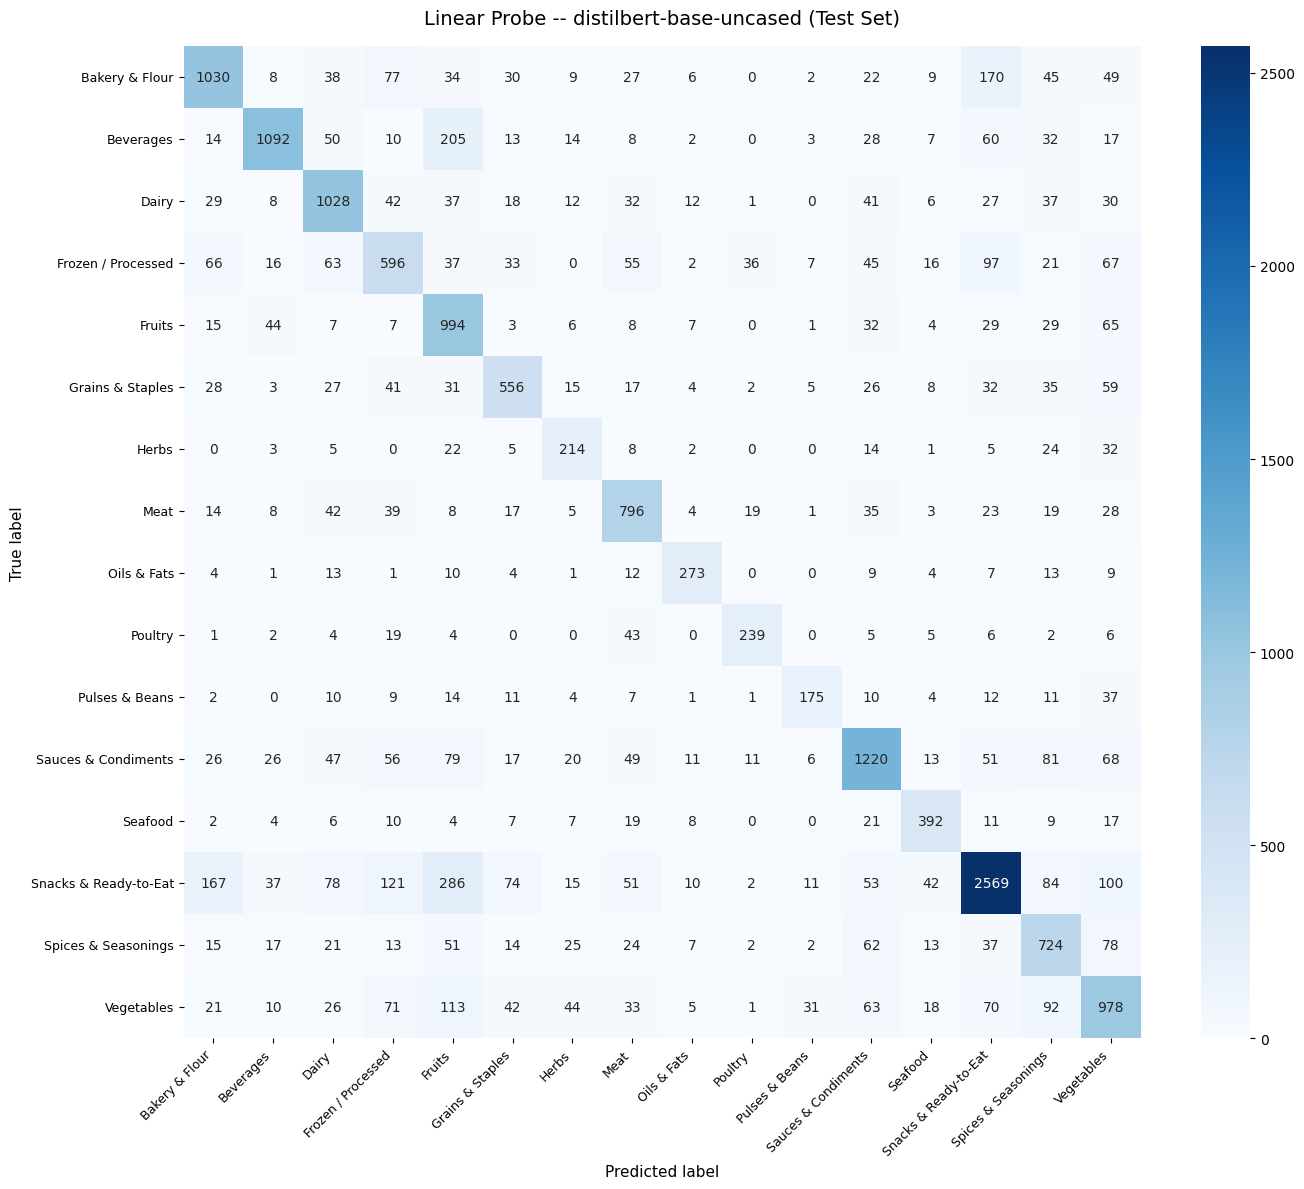

Confusion matrix saved -> results\linear_probe_distilbert_confusion.png

Metrics saved -> results\linear_probe_distilbert_results.json


In [7]:
# ═══════════════════════════════════════════════════════════════════
# Cell 5 — Linear Probe: DistilBERT
# Frozen encoder + single trainable nn.Linear(768, 16) head
# ═══════════════════════════════════════════════════════════════════

class LinearProbeModel(nn.Module):
    """Pretrained encoder (fully frozen) + trainable linear head.

    Architecture: [CLS] embedding (768-d) -> nn.Linear(768, 16) -> logits
    Only the classifier head trains; the encoder is completely frozen.
    This cell defines the class for reuse in Cell 6.
    """
    def __init__(self, model_name: str, num_labels: int):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        for param in self.encoder.parameters():
            param.requires_grad = False           # freeze entire encoder
        hidden = self.encoder.config.hidden_size  # 768 for DistilBERT & RoBERTa
        self.classifier = nn.Linear(hidden, num_labels)

    def forward(
        self,
        input_ids:      torch.Tensor,
        attention_mask: torch.Tensor,
    ) -> torch.Tensor:
        enc_out   = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_embed = enc_out.last_hidden_state[:, 0, :]  # [CLS] token  (batch, 768)
        return self.classifier(cls_embed)               # logits       (batch, 16)


# ── Run config for this cell ──────────────────────────────────────
MODEL_NAME = "distilbert-base-uncased"
CKPT_PATH  = os.path.join(config["checkpoint_dir"], "linear_probe_distilbert_best.pt")
CM_PATH    = os.path.join(config["results_dir"],    "linear_probe_distilbert_confusion.png")
JSON_PATH  = os.path.join(config["results_dir"],    "linear_probe_distilbert_results.json")

print(f"{'='*60}")
print(f"  Linear Probe: {MODEL_NAME}")
print(f"{'='*60}")

# ── DataLoaders ───────────────────────────────────────────────────
_, train_loader, val_loader, test_loader = get_dataloaders(MODEL_NAME)

# ── Model, optimizer, loss ────────────────────────────────────────
model     = LinearProbeModel(MODEL_NAME, config["num_labels"]).to(config["device"])
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total params    : {total:,}")
print(f"  Trainable params: {trainable:,}  ({100*trainable/total:.2f}% -- head only)")

optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=config["lr_linear_probe"],
)
loss_fn = nn.CrossEntropyLoss()

# ── Training loop with early stopping on val macro-F1 ─────────────
best_val_f1, patience_count, best_epoch = -1.0, 0, 0
history = []

print(f"\n{'Epoch':>5}  {'Train Loss':>10}  {'Val Loss':>8}  "
      f"{'Val Acc':>7}  {'Val F1':>7}  Best?")
print("-" * 58)

for epoch in range(1, config["epochs"] + 1):
    tr_loss = train_epoch(model, train_loader, optimizer, loss_fn, config["device"])
    val_m   = evaluate(model, val_loader, loss_fn, config["device"])
    is_best = val_m["macro_f1"] > best_val_f1

    if is_best:
        best_val_f1    = val_m["macro_f1"]
        best_epoch     = epoch
        patience_count = 0
        torch.save(model.state_dict(), CKPT_PATH)
    else:
        patience_count += 1

    flag = "<-- best" if is_best else ""
    print(f"{epoch:>5}  {tr_loss:>10.4f}  {val_m['loss']:>8.4f}  "
          f"{val_m['accuracy']:>7.4f}  {val_m['macro_f1']:>7.4f}  {flag}")
    history.append({
        "epoch":        epoch,
        "train_loss":   round(tr_loss, 6),
        "val_loss":     round(val_m["loss"],     6),
        "val_accuracy": round(val_m["accuracy"], 6),
        "val_macro_f1": round(val_m["macro_f1"], 6),
    })

    if patience_count >= config["patience"]:
        print(f"\nEarly stopping at epoch {epoch} "
              f"(no val F1 improvement for {config['patience']} epochs).")
        break

print(f"\nBest checkpoint: epoch {best_epoch}  |  val macro-F1 = {best_val_f1:.4f}")
print(f"Checkpoint saved -> {CKPT_PATH}")

# ── Evaluate on test set using best checkpoint ────────────────────
print("\nLoading best checkpoint for test evaluation...")
model.load_state_dict(
    torch.load(CKPT_PATH, map_location=config["device"], weights_only=True)
)
test_m = evaluate(model, test_loader, loss_fn, config["device"])

print(f"\nTest Results -- {MODEL_NAME}")
print(f"  Accuracy : {test_m['accuracy']:.4f}")
print(f"  Macro-F1 : {test_m['macro_f1']:.4f}")
print("\nPer-class F1:")
for lbl, f1v in sorted(test_m["per_class_f1"].items()):
    print(f"  {lbl:<30} {f1v:.4f}")
print("\nClassification Report:")
print(classification_report(
    test_m["all_labels"], test_m["all_preds"],
    target_names=CATEGORIES, zero_division=0,
))

# ── Save confusion matrix ─────────────────────────────────────────
cm = confusion_matrix(
    test_m["all_labels"], test_m["all_preds"],
    labels=list(range(len(CATEGORIES))),
)
plot_confusion_matrix(cm, f"Linear Probe -- {MODEL_NAME} (Test Set)", CM_PATH)

# ── Save metrics to JSON immediately ─────────────────────────────
results_distilbert_lp = {
    "model":             MODEL_NAME,
    "method":            "linear_probe",
    "test_accuracy":     round(test_m["accuracy"], 6),
    "test_macro_f1":     round(test_m["macro_f1"],  6),
    "per_class_f1":      test_m["per_class_f1"],
    "best_val_macro_f1": round(best_val_f1, 6),
    "best_epoch":        best_epoch,
    "training_history":  history,
    "checkpoint":        CKPT_PATH,
}
with open(JSON_PATH, "w") as f:
    json.dump(results_distilbert_lp, f, indent=2)
print(f"\nMetrics saved -> {JSON_PATH}")

  Linear Probe: roberta-base
  [roberta-base]  train=101,974  val=18,889  test=18,890


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5371.23it/s]
RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Total params    : 124,657,936
  Trainable params: 12,304  (0.01% -- head only)

Epoch  Train Loss  Val Loss  Val Acc   Val F1  Best?
----------------------------------------------------------
    1      2.4337    2.1796   0.5242   0.3943  <-- best
    2      2.1232    1.9644   0.5502   0.4485  <-- best
    3      1.9734    1.8032   0.5835   0.5150  <-- best
    4      1.8926    1.6926   0.6086   0.5429  <-- best
    5      1.8432    1.6424   0.6121   0.5638  <-- best
    6      1.8039    1.6050   0.6064   0.5594  
    7      1.7733    1.5623   0.6222   0.5723  <-- best
    8      1.7587    1.5557   0.6081   0.5748  <-- best
    9      1.7410    1.5023   0.6349   0.5934  <-- best
   10      1.7262    1.4941   0.6351   0.5987  <-- best
   11      1.7245    1.5125   0.6152   0.5938  
   12      1.7110    1.4722   0.6340   0.6089  <-- best
   13      1.7098    1.4822   0.6227   0.6035  
   14      1.7024    1.4572   0.6342   0.6054  
   15      1.6935    1.4844   0.6115   0.5882  

Early

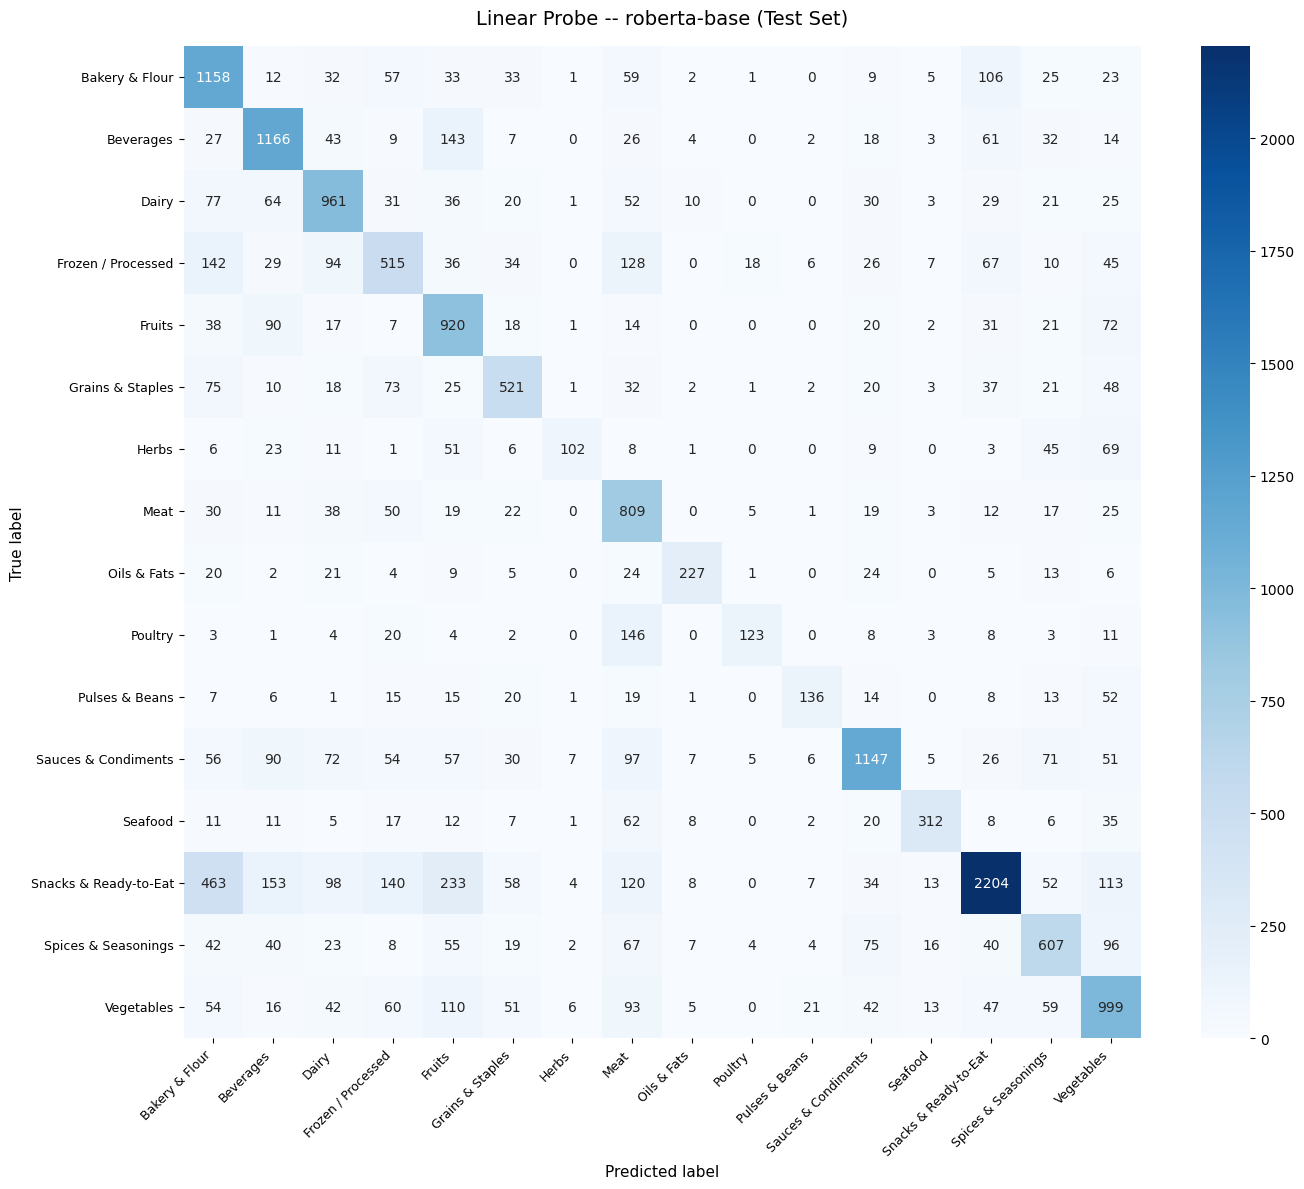

Confusion matrix saved -> results\linear_probe_roberta_confusion.png

Metrics saved -> results\linear_probe_roberta_results.json


In [8]:
# ═══════════════════════════════════════════════════════════════════
# Cell 6 — Linear Probe: RoBERTa
# Identical structure to Cell 5. LinearProbeModel defined in Cell 5.
# ═══════════════════════════════════════════════════════════════════

MODEL_NAME = "roberta-base"
CKPT_PATH  = os.path.join(config["checkpoint_dir"], "linear_probe_roberta_best.pt")
CM_PATH    = os.path.join(config["results_dir"],    "linear_probe_roberta_confusion.png")
JSON_PATH  = os.path.join(config["results_dir"],    "linear_probe_roberta_results.json")

print(f"{'='*60}")
print(f"  Linear Probe: {MODEL_NAME}")
print(f"{'='*60}")

# ── DataLoaders ───────────────────────────────────────────────────
_, train_loader, val_loader, test_loader = get_dataloaders(MODEL_NAME)

# ── Model, optimizer, loss ────────────────────────────────────────
model     = LinearProbeModel(MODEL_NAME, config["num_labels"]).to(config["device"])
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total params    : {total:,}")
print(f"  Trainable params: {trainable:,}  ({100*trainable/total:.2f}% -- head only)")

optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=config["lr_linear_probe"],
)
loss_fn = nn.CrossEntropyLoss()

# ── Training loop with early stopping on val macro-F1 ─────────────
best_val_f1, patience_count, best_epoch = -1.0, 0, 0
history = []

print(f"\n{'Epoch':>5}  {'Train Loss':>10}  {'Val Loss':>8}  "
      f"{'Val Acc':>7}  {'Val F1':>7}  Best?")
print("-" * 58)

for epoch in range(1, config["epochs"] + 1):
    tr_loss = train_epoch(model, train_loader, optimizer, loss_fn, config["device"])
    val_m   = evaluate(model, val_loader, loss_fn, config["device"])
    is_best = val_m["macro_f1"] > best_val_f1

    if is_best:
        best_val_f1    = val_m["macro_f1"]
        best_epoch     = epoch
        patience_count = 0
        torch.save(model.state_dict(), CKPT_PATH)
    else:
        patience_count += 1

    flag = "<-- best" if is_best else ""
    print(f"{epoch:>5}  {tr_loss:>10.4f}  {val_m['loss']:>8.4f}  "
          f"{val_m['accuracy']:>7.4f}  {val_m['macro_f1']:>7.4f}  {flag}")
    history.append({
        "epoch":        epoch,
        "train_loss":   round(tr_loss, 6),
        "val_loss":     round(val_m["loss"],     6),
        "val_accuracy": round(val_m["accuracy"], 6),
        "val_macro_f1": round(val_m["macro_f1"], 6),
    })

    if patience_count >= config["patience"]:
        print(f"\nEarly stopping at epoch {epoch} "
              f"(no val F1 improvement for {config['patience']} epochs).")
        break

print(f"\nBest checkpoint: epoch {best_epoch}  |  val macro-F1 = {best_val_f1:.4f}")
print(f"Checkpoint saved -> {CKPT_PATH}")

# ── Evaluate on test set using best checkpoint ────────────────────
print("\nLoading best checkpoint for test evaluation...")
model.load_state_dict(
    torch.load(CKPT_PATH, map_location=config["device"], weights_only=True)
)
test_m = evaluate(model, test_loader, loss_fn, config["device"])

print(f"\nTest Results -- {MODEL_NAME}")
print(f"  Accuracy : {test_m['accuracy']:.4f}")
print(f"  Macro-F1 : {test_m['macro_f1']:.4f}")
print("\nPer-class F1:")
for lbl, f1v in sorted(test_m["per_class_f1"].items()):
    print(f"  {lbl:<30} {f1v:.4f}")
print("\nClassification Report:")
print(classification_report(
    test_m["all_labels"], test_m["all_preds"],
    target_names=CATEGORIES, zero_division=0,
))

# ── Save confusion matrix ─────────────────────────────────────────
cm = confusion_matrix(
    test_m["all_labels"], test_m["all_preds"],
    labels=list(range(len(CATEGORIES))),
)
plot_confusion_matrix(cm, f"Linear Probe -- {MODEL_NAME} (Test Set)", CM_PATH)

# ── Save metrics to JSON immediately ─────────────────────────────
results_roberta_lp = {
    "model":             MODEL_NAME,
    "method":            "linear_probe",
    "test_accuracy":     round(test_m["accuracy"], 6),
    "test_macro_f1":     round(test_m["macro_f1"],  6),
    "per_class_f1":      test_m["per_class_f1"],
    "best_val_macro_f1": round(best_val_f1, 6),
    "best_epoch":        best_epoch,
    "training_history":  history,
    "checkpoint":        CKPT_PATH,
}
with open(JSON_PATH, "w") as f:
    json.dump(results_roberta_lp, f, indent=2)
print(f"\nMetrics saved -> {JSON_PATH}")

In [9]:
# ═══════════════════════════════════════════════════════════════════
# Cell 7 — Linear Probe: Side-by-Side Comparison
# Self-contained: loads only from saved JSON files, no model in memory.
# ═══════════════════════════════════════════════════════════════════

import json as _json, os as _os
import pandas as _pd

_rdir = config["results_dir"] if "config" in dir() else "results"

_lp_files = {
    "DistilBERT LP": _os.path.join(_rdir, "linear_probe_distilbert_results.json"),
    "RoBERTa LP":    _os.path.join(_rdir, "linear_probe_roberta_results.json"),
}

_lp_data = {}
for _label, _path in _lp_files.items():
    if _os.path.exists(_path):
        with open(_path) as _f:
            _lp_data[_label] = _json.load(_f)
    else:
        print(f"WARNING: {_path} not found -- run Cell 5 / Cell 6 first.")

if not _lp_data:
    raise FileNotFoundError("No linear probe result files found.")

# ── Summary table ─────────────────────────────────────────────────
print("=" * 60)
print("  LINEAR PROBE COMPARISON: DistilBERT vs RoBERTa")
print("=" * 60)

_rows = []
for _label, _res in _lp_data.items():
    _rows.append({
        "Model":         _label,
        "Test Accuracy": f"{_res['test_accuracy']:.4f}",
        "Test Macro-F1": f"{_res['test_macro_f1']:.4f}",
        "Best Val F1":   f"{_res['best_val_macro_f1']:.4f}",
        "Best Epoch":    _res["best_epoch"],
    })
_sum_df = _pd.DataFrame(_rows).set_index("Model")
print(_sum_df.to_string())

# ── Per-class F1 side by side ─────────────────────────────────────
print("\nPer-class F1:")
_pc_df = _pd.DataFrame({
    _label: _res["per_class_f1"] for _label, _res in _lp_data.items()
}).sort_index()
_pc_df.index.name = "Category"
print(_pc_df.to_string(float_format="{:.4f}".format))

  LINEAR PROBE COMPARISON: DistilBERT vs RoBERTa
              Test Accuracy Test Macro-F1 Best Val F1  Best Epoch
Model                                                            
DistilBERT LP        0.6816        0.6756      0.6796          14
RoBERTa LP           0.6303        0.6062      0.6089          12

Per-class F1:
                       DistilBERT LP  RoBERTa LP
Category                                        
Bakery & Flour                0.6890      0.6151
Beverages                     0.7706      0.7112
Dairy                         0.7278      0.6768
Frozen / Processed            0.5253      0.4644
Fruits                        0.6252      0.6115
Grains & Staples              0.6417      0.5982
Herbs                         0.5895      0.4416
Meat                          0.7076      0.5744
Oils & Fats                   0.7636      0.7061
Poultry                       0.7354      0.4980
Pulses & Beans                0.6341      0.5495
Sauces & Condiments           0.703

  LoRA Fine-tuning: distilbert-base-uncased
  [distilbert-base-uncased]  train=101,974  val=18,889  test=18,890


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 5837.34it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Total params    : 67,716,128
  Trainable params: 750,352  (1.108% -- LoRA adapters + classifier head)


`use_return_dict` is deprecated! Use `return_dict` instead!


  Total steps : 47,805  |  Warmup steps: 2,868 (6%)

Epoch  Train Loss  Val Loss  Val Acc   Val F1  Best?
----------------------------------------------------------
    1      1.2834    0.7560   0.7596   0.7554  <-- best
    2      0.7255    0.6017   0.8094   0.8030  <-- best
    3      0.6055    0.5340   0.8263   0.8164  <-- best
    4      0.5360    0.5218   0.8304   0.8230  <-- best
    5      0.4937    0.4960   0.8394   0.8325  <-- best
    6      0.4562    0.4647   0.8489   0.8395  <-- best
    7      0.4276    0.4602   0.8489   0.8393  
    8      0.4032    0.4572   0.8507   0.8445  <-- best
    9      0.3821    0.4620   0.8492   0.8438  
   10      0.3655    0.4427   0.8543   0.8479  <-- best
   11      0.3511    0.4288   0.8617   0.8529  <-- best
   12      0.3385    0.4412   0.8567   0.8501  
   13      0.3249    0.4244   0.8612   0.8536  <-- best
   14      0.3193    0.4299   0.8615   0.8542  <-- best
   15      0.3094    0.4278   0.8613   0.8537  

Best checkpoint: epoch 14 

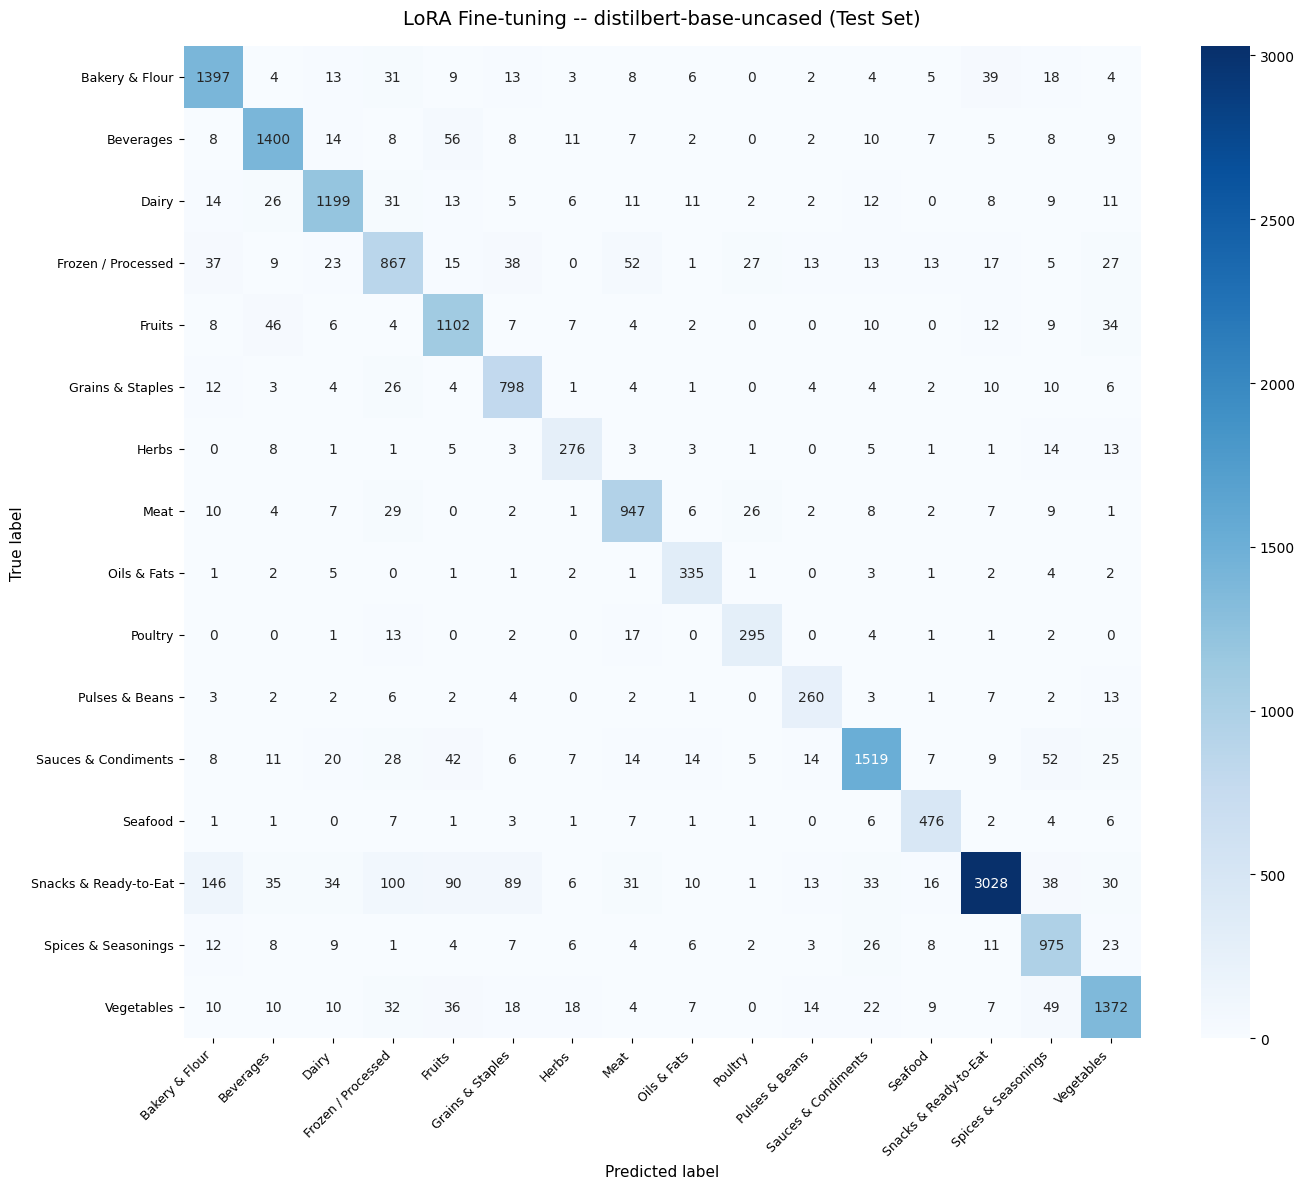

Confusion matrix saved -> results\lora_distilbert_confusion.png

Metrics saved -> results\lora_distilbert_results.json


In [10]:
# ═══════════════════════════════════════════════════════════════════
# Cell 8 — LoRA Fine-tuning: DistilBERT
# PEFT adapters inserted into q_lin / v_lin attention projections
# Saves: PEFT adapter dir + merged model .pt + confusion PNG + JSON
# ═══════════════════════════════════════════════════════════════════

def build_lora_model(model_name: str) -> nn.Module:
    """Load AutoModelForSequenceClassification and wrap with LoRA adapters.
    Reads all LoRA hyperparameters from the global config dict.
    Defined here for reuse in Cell 9.
    """
    base = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=config["num_labels"],
        id2label=id2label,
        label2id=label2id,
    )
    peft_cfg = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=config["lora_r"],
        lora_alpha=config["lora_alpha"],
        lora_dropout=config["lora_dropout"],
        bias=config["lora_bias"],
        target_modules=config["lora_targets"][model_name],
    )
    model = get_peft_model(base, peft_cfg)
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Total params    : {total:,}")
    print(f"  Trainable params: {trainable:,}  "
          f"({100 * trainable / total:.3f}% -- LoRA adapters + classifier head)")
    return model


# ── Run config for this cell ──────────────────────────────────────
MODEL_NAME  = "distilbert-base-uncased"
TMP_CKPT    = os.path.join(config["checkpoint_dir"], "lora_distilbert_tmp.pt")
ADAPTER_DIR = os.path.join(config["checkpoint_dir"], "lora_distilbert_adapter")
MERGED_PT   = os.path.join(config["checkpoint_dir"], "lora_distilbert_merged.pt")
CM_PATH     = os.path.join(config["results_dir"],    "lora_distilbert_confusion.png")
JSON_PATH   = os.path.join(config["results_dir"],    "lora_distilbert_results.json")

print(f"{'='*60}")
print(f"  LoRA Fine-tuning: {MODEL_NAME}")
print(f"{'='*60}")

# ── DataLoaders ───────────────────────────────────────────────────
_, train_loader, val_loader, test_loader = get_dataloaders(MODEL_NAME)

# ── Model, optimizer, scheduler, loss ────────────────────────────
model     = build_lora_model(MODEL_NAME).to(config["device"])
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=config["lr_lora"],
)
total_steps  = len(train_loader) * config["epochs"]
warmup_steps = int(config["warmup_ratio"] * total_steps)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)
loss_fn = nn.CrossEntropyLoss()
print(f"  Total steps : {total_steps:,}  |  Warmup steps: {warmup_steps:,} "
      f"({config['warmup_ratio']*100:.0f}%)")

# ── Training loop with early stopping on val macro-F1 ─────────────
best_val_f1, patience_count, best_epoch = -1.0, 0, 0
history = []

print(f"\n{'Epoch':>5}  {'Train Loss':>10}  {'Val Loss':>8}  "
      f"{'Val Acc':>7}  {'Val F1':>7}  Best?")
print("-" * 58)

for epoch in range(1, config["epochs"] + 1):
    tr_loss = train_epoch(
        model, train_loader, optimizer, loss_fn, config["device"],
        scheduler=scheduler,
    )
    val_m   = evaluate(model, val_loader, loss_fn, config["device"])
    is_best = val_m["macro_f1"] > best_val_f1

    if is_best:
        best_val_f1    = val_m["macro_f1"]
        best_epoch     = epoch
        patience_count = 0
        torch.save(model.state_dict(), TMP_CKPT)
    else:
        patience_count += 1

    flag = "<-- best" if is_best else ""
    print(f"{epoch:>5}  {tr_loss:>10.4f}  {val_m['loss']:>8.4f}  "
          f"{val_m['accuracy']:>7.4f}  {val_m['macro_f1']:>7.4f}  {flag}")
    history.append({
        "epoch":        epoch,
        "train_loss":   round(tr_loss, 6),
        "val_loss":     round(val_m["loss"],     6),
        "val_accuracy": round(val_m["accuracy"], 6),
        "val_macro_f1": round(val_m["macro_f1"], 6),
    })

    if patience_count >= config["patience"]:
        print(f"\nEarly stopping at epoch {epoch} "
              f"(no val F1 improvement for {config['patience']} epochs).")
        break

print(f"\nBest checkpoint: epoch {best_epoch}  |  val macro-F1 = {best_val_f1:.4f}")

# ── Save model weights immediately after training completes ───────
model.load_state_dict(
    torch.load(TMP_CKPT, map_location=config["device"], weights_only=True)
)

# 1. Save PEFT adapter (adapter weights only)
os.makedirs(ADAPTER_DIR, exist_ok=True)
model.save_pretrained(ADAPTER_DIR)
print(f"PEFT adapter saved  -> {ADAPTER_DIR}")

# 2. Merge LoRA weights into base model and save full state dict
merged_model = model.merge_and_unload()
torch.save(merged_model.state_dict(), MERGED_PT)
print(f"Merged model saved  -> {MERGED_PT}")

# ── Evaluate on test set (merged model) ───────────────────────────
print("\nEvaluating on test set (merged model)...")
test_m = evaluate(merged_model, test_loader, loss_fn, config["device"])

print(f"\nTest Results -- {MODEL_NAME}")
print(f"  Accuracy : {test_m['accuracy']:.4f}")
print(f"  Macro-F1 : {test_m['macro_f1']:.4f}")
print("\nPer-class F1:")
for lbl, f1v in sorted(test_m["per_class_f1"].items()):
    print(f"  {lbl:<30} {f1v:.4f}")
print("\nClassification Report:")
print(classification_report(
    test_m["all_labels"], test_m["all_preds"],
    target_names=CATEGORIES, zero_division=0,
))

# ── Save confusion matrix ─────────────────────────────────────────
cm = confusion_matrix(
    test_m["all_labels"], test_m["all_preds"],
    labels=list(range(len(CATEGORIES))),
)
plot_confusion_matrix(cm, f"LoRA Fine-tuning -- {MODEL_NAME} (Test Set)", CM_PATH)

# ── Save metrics to JSON immediately ─────────────────────────────
results_distilbert_lora = {
    "model":             MODEL_NAME,
    "method":            "lora",
    "test_accuracy":     round(test_m["accuracy"], 6),
    "test_macro_f1":     round(test_m["macro_f1"],  6),
    "per_class_f1":      test_m["per_class_f1"],
    "best_val_macro_f1": round(best_val_f1, 6),
    "best_epoch":        best_epoch,
    "training_history":  history,
    "adapter_dir":       ADAPTER_DIR,
    "merged_checkpoint": MERGED_PT,
}
with open(JSON_PATH, "w") as f:
    json.dump(results_distilbert_lora, f, indent=2)
print(f"\nMetrics saved -> {JSON_PATH}")

if os.path.exists(TMP_CKPT):
    os.remove(TMP_CKPT)

  LoRA Fine-tuning: roberta-base
  [roberta-base]  train=101,974  val=18,889  test=18,890


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4621.91it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Total params    : 125,555,744
  Trainable params: 897,808  (0.715% -- LoRA adapters + classifier head)
  Total steps : 47,805  |  Warmup steps: 2,868 (6%)

Epoch  Train Loss  Val Loss  Val Acc   Val F1  Best?
----------------------------------------------------------
    1      1.2471    0.7474   0.7701   0.7606  <-- best
    2      0.7832    0.6400   0.8030   0.7965  <-- best
    3      0.6875    0.5906   0.8117   0.8070  <-- best
    4      0.6259    0.5426   0.8250   0.8192  <-- best
    5      0.5885    0.5334   0.8276   0.8228  <-- best
    6      0.5553    0.5390   0.8316   0.8271  <-- best
    7      0.5292    0.4827   0.8421   0.8342  <-- best
    8      0.5059    0.5090   0.8372   0.8314  
    9      0.4897    0.4858   0.8433   0.8376  <-- best
   10      0.4742    0.4713   0.8477   0.8408  <-- best
   11      0.4604    0.4787   0.8450   0.8397  
   12      0.4500    0.4627   0.8503   0.8444  <-- best
   13      0.4398    0.4556   0.8531   0.8476  <-- best
   14      0.4305 

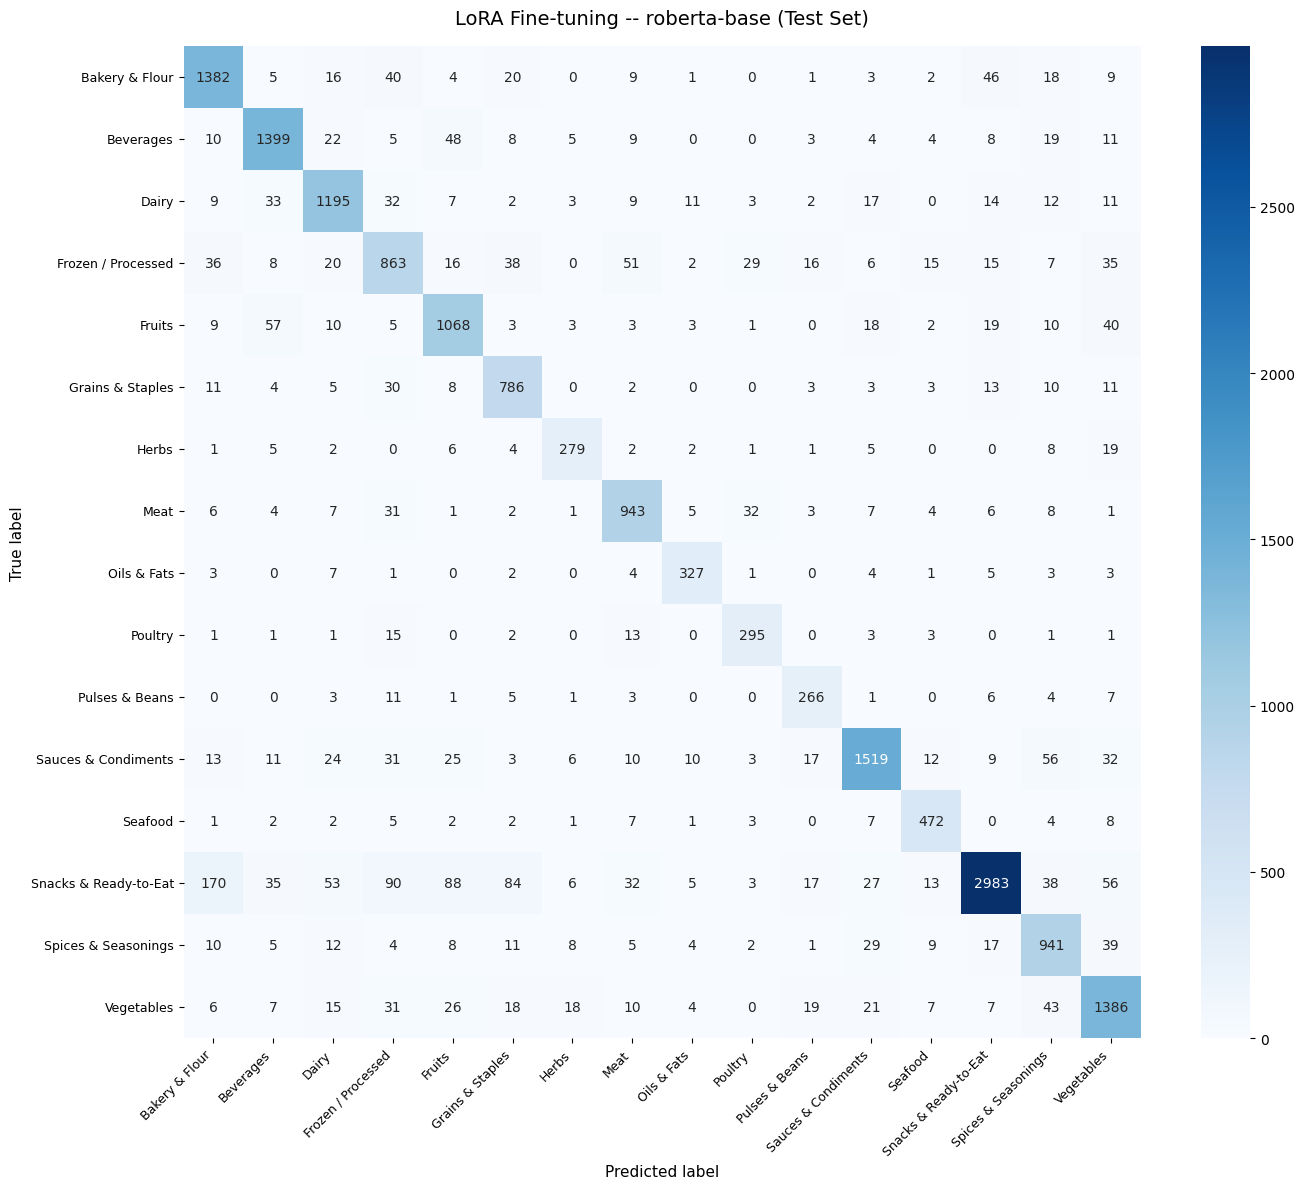

Confusion matrix saved -> results\lora_roberta_confusion.png

Metrics saved -> results\lora_roberta_results.json


In [11]:
# ═══════════════════════════════════════════════════════════════════
# Cell 9 — LoRA Fine-tuning: RoBERTa
# Identical structure to Cell 8. build_lora_model defined in Cell 8.
# target_modules = ["query", "value"]
# ═══════════════════════════════════════════════════════════════════

MODEL_NAME  = "roberta-base"
TMP_CKPT    = os.path.join(config["checkpoint_dir"], "lora_roberta_tmp.pt")
ADAPTER_DIR = os.path.join(config["checkpoint_dir"], "lora_roberta_adapter")
MERGED_PT   = os.path.join(config["checkpoint_dir"], "lora_roberta_merged.pt")
CM_PATH     = os.path.join(config["results_dir"],    "lora_roberta_confusion.png")
JSON_PATH   = os.path.join(config["results_dir"],    "lora_roberta_results.json")

print(f"{'='*60}")
print(f"  LoRA Fine-tuning: {MODEL_NAME}")
print(f"{'='*60}")

# ── DataLoaders ───────────────────────────────────────────────────
_, train_loader, val_loader, test_loader = get_dataloaders(MODEL_NAME)

# ── Model, optimizer, scheduler, loss ────────────────────────────
model     = build_lora_model(MODEL_NAME).to(config["device"])
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=config["lr_lora"],
)
total_steps  = len(train_loader) * config["epochs"]
warmup_steps = int(config["warmup_ratio"] * total_steps)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)
loss_fn = nn.CrossEntropyLoss()
print(f"  Total steps : {total_steps:,}  |  Warmup steps: {warmup_steps:,} "
      f"({config['warmup_ratio']*100:.0f}%)")

# ── Training loop with early stopping on val macro-F1 ─────────────
best_val_f1, patience_count, best_epoch = -1.0, 0, 0
history = []

print(f"\n{'Epoch':>5}  {'Train Loss':>10}  {'Val Loss':>8}  "
      f"{'Val Acc':>7}  {'Val F1':>7}  Best?")
print("-" * 58)

for epoch in range(1, config["epochs"] + 1):
    tr_loss = train_epoch(
        model, train_loader, optimizer, loss_fn, config["device"],
        scheduler=scheduler,
    )
    val_m   = evaluate(model, val_loader, loss_fn, config["device"])
    is_best = val_m["macro_f1"] > best_val_f1

    if is_best:
        best_val_f1    = val_m["macro_f1"]
        best_epoch     = epoch
        patience_count = 0
        torch.save(model.state_dict(), TMP_CKPT)
    else:
        patience_count += 1

    flag = "<-- best" if is_best else ""
    print(f"{epoch:>5}  {tr_loss:>10.4f}  {val_m['loss']:>8.4f}  "
          f"{val_m['accuracy']:>7.4f}  {val_m['macro_f1']:>7.4f}  {flag}")
    history.append({
        "epoch":        epoch,
        "train_loss":   round(tr_loss, 6),
        "val_loss":     round(val_m["loss"],     6),
        "val_accuracy": round(val_m["accuracy"], 6),
        "val_macro_f1": round(val_m["macro_f1"], 6),
    })

    if patience_count >= config["patience"]:
        print(f"\nEarly stopping at epoch {epoch} "
              f"(no val F1 improvement for {config['patience']} epochs).")
        break

print(f"\nBest checkpoint: epoch {best_epoch}  |  val macro-F1 = {best_val_f1:.4f}")

# ── Save model weights immediately after training completes ───────
model.load_state_dict(
    torch.load(TMP_CKPT, map_location=config["device"], weights_only=True)
)

os.makedirs(ADAPTER_DIR, exist_ok=True)
model.save_pretrained(ADAPTER_DIR)
print(f"PEFT adapter saved  -> {ADAPTER_DIR}")

merged_model = model.merge_and_unload()
torch.save(merged_model.state_dict(), MERGED_PT)
print(f"Merged model saved  -> {MERGED_PT}")

# ── Evaluate on test set (merged model) ───────────────────────────
print("\nEvaluating on test set (merged model)...")
test_m = evaluate(merged_model, test_loader, loss_fn, config["device"])

print(f"\nTest Results -- {MODEL_NAME}")
print(f"  Accuracy : {test_m['accuracy']:.4f}")
print(f"  Macro-F1 : {test_m['macro_f1']:.4f}")
print("\nPer-class F1:")
for lbl, f1v in sorted(test_m["per_class_f1"].items()):
    print(f"  {lbl:<30} {f1v:.4f}")
print("\nClassification Report:")
print(classification_report(
    test_m["all_labels"], test_m["all_preds"],
    target_names=CATEGORIES, zero_division=0,
))

# ── Save confusion matrix ─────────────────────────────────────────
cm = confusion_matrix(
    test_m["all_labels"], test_m["all_preds"],
    labels=list(range(len(CATEGORIES))),
)
plot_confusion_matrix(cm, f"LoRA Fine-tuning -- {MODEL_NAME} (Test Set)", CM_PATH)

# ── Save metrics to JSON immediately ─────────────────────────────
results_roberta_lora = {
    "model":             MODEL_NAME,
    "method":            "lora",
    "test_accuracy":     round(test_m["accuracy"], 6),
    "test_macro_f1":     round(test_m["macro_f1"],  6),
    "per_class_f1":      test_m["per_class_f1"],
    "best_val_macro_f1": round(best_val_f1, 6),
    "best_epoch":        best_epoch,
    "training_history":  history,
    "adapter_dir":       ADAPTER_DIR,
    "merged_checkpoint": MERGED_PT,
}
with open(JSON_PATH, "w") as f:
    json.dump(results_roberta_lora, f, indent=2)
print(f"\nMetrics saved -> {JSON_PATH}")

if os.path.exists(TMP_CKPT):
    os.remove(TMP_CKPT)

In [12]:
# ═══════════════════════════════════════════════════════════════════
# Cell 10 — Full Comparison: All 4 Models
# Self-contained: loads from saved JSON files only.
# Highlights the best F1 per class with a * marker.
# ═══════════════════════════════════════════════════════════════════

import json as _json, os as _os
import pandas as _pd

_rdir = config["results_dir"] if "config" in dir() else "results"

_result_files = {
    "DistilBERT LP":   _os.path.join(_rdir, "linear_probe_distilbert_results.json"),
    "RoBERTa LP":      _os.path.join(_rdir, "linear_probe_roberta_results.json"),
    "DistilBERT LoRA": _os.path.join(_rdir, "lora_distilbert_results.json"),
    "RoBERTa LoRA":    _os.path.join(_rdir, "lora_roberta_results.json"),
}

_all_data = {}
for _label, _path in _result_files.items():
    if _os.path.exists(_path):
        with open(_path) as _f:
            _all_data[_label] = _json.load(_f)
    else:
        print(f"WARNING: {_path} not found -- skipping {_label}.")

if not _all_data:
    raise FileNotFoundError("No result files found. Run Cells 5, 6, 8, 9 first.")

# ── Summary table: Accuracy & Macro-F1 ───────────────────────────
print("=" * 72)
print("  FULL COMPARISON: Linear Probe vs LoRA  |  DistilBERT & RoBERTa")
print("=" * 72)

_rows = []
for _label, _res in _all_data.items():
    _rows.append({
        "Variant":       _label,
        "Test Accuracy": f"{_res['test_accuracy']:.4f}",
        "Test Macro-F1": f"{_res['test_macro_f1']:.4f}",
        "Best Val F1":   f"{_res['best_val_macro_f1']:.4f}",
        "Best Epoch":    _res["best_epoch"],
    })
_sum_df = _pd.DataFrame(_rows).set_index("Variant")
print(_sum_df.to_string())

# ── Per-class F1 with best-per-class highlighting ─────────────────
print("\nPer-class F1 (best value per category marked with *):\n")
_pc_df = _pd.DataFrame({
    _label: _res["per_class_f1"] for _label, _res in _all_data.items()
}).sort_index()
_pc_df.index.name = "Category"

_display_rows = []
for _cat, _row in _pc_df.iterrows():
    _best = _row.max()
    _marked = {
        _col: (f"{_v:.4f}*" if _v == _best else f"{_v:.4f}")
        for _col, _v in _row.items()
    }
    _marked["Category"] = _cat
    _display_rows.append(_marked)

_display_df = _pd.DataFrame(_display_rows).set_index("Category")
print(_display_df.to_string())

  FULL COMPARISON: Linear Probe vs LoRA  |  DistilBERT & RoBERTa
                Test Accuracy Test Macro-F1 Best Val F1  Best Epoch
Variant                                                            
DistilBERT LP          0.6816        0.6756      0.6796          14
RoBERTa LP             0.6303        0.6062      0.6089          12
DistilBERT LoRA        0.8600        0.8527      0.8542          14
RoBERTa LoRA           0.8525        0.8478      0.8476          13

Per-class F1 (best value per category marked with *):

                      DistilBERT LP RoBERTa LP DistilBERT LoRA RoBERTa LoRA
Category                                                                   
Bakery & Flour               0.6890     0.6151         0.8669*       0.8573
Beverages                    0.7706     0.7112         0.8963*       0.8936
Dairy                        0.7278     0.6768         0.8855*       0.8678
Frozen / Processed           0.5253     0.4644         0.7407*       0.7342
Fruits         

  Full Fine-Tuning (Unweighted): distilbert-base-uncased
  Discriminative LR — lower half: 1e-05  |  upper half: 3e-05
  [distilbert-base-uncased]  train=101,974  val=18,889  test=18,890


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6590.57it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Total params    : 66,965,776
  Trainable params: 66,965,776  (100.00% — all layers)
  LR group 1 (lower half): 52 param tensors  lr=1e-05
  LR group 2 (upper half): 52 param tensors  lr=3e-05
  Total steps : 47,805  |  Warmup steps: 2,868 (6%)

Epoch  Train Loss  Val Loss  Val Acc   Val F1  Best?
----------------------------------------------------------
    1      1.1906    0.5997   0.8118   0.8073  <-- best
    2      0.4951    0.4316   0.8602   0.8535  <-- best
    3      0.3590    0.4515   0.8577   0.8522  
    4      0.2750    0.4038   0.8721   0.8660  <-- best
    5      0.2121    0.4398   0.8691   0.8652  
    6      0.1667    0.4585   0.8716   0.8658  
    7      0.1336    0.4714   0.8722   0.8662  <-- best
    8      0.1077    0.5180   0.8699   0.8634  
    9      0.0873    0.5242   0.8731   0.8668  <-- best
   10      0.0722    0.5520   0.8698   0.8655  
   11      0.0587    0.5900   0.8701   0.8660  
   12      0.0485    0.6059   0.8705   0.8660  

Early stopping at epoch 

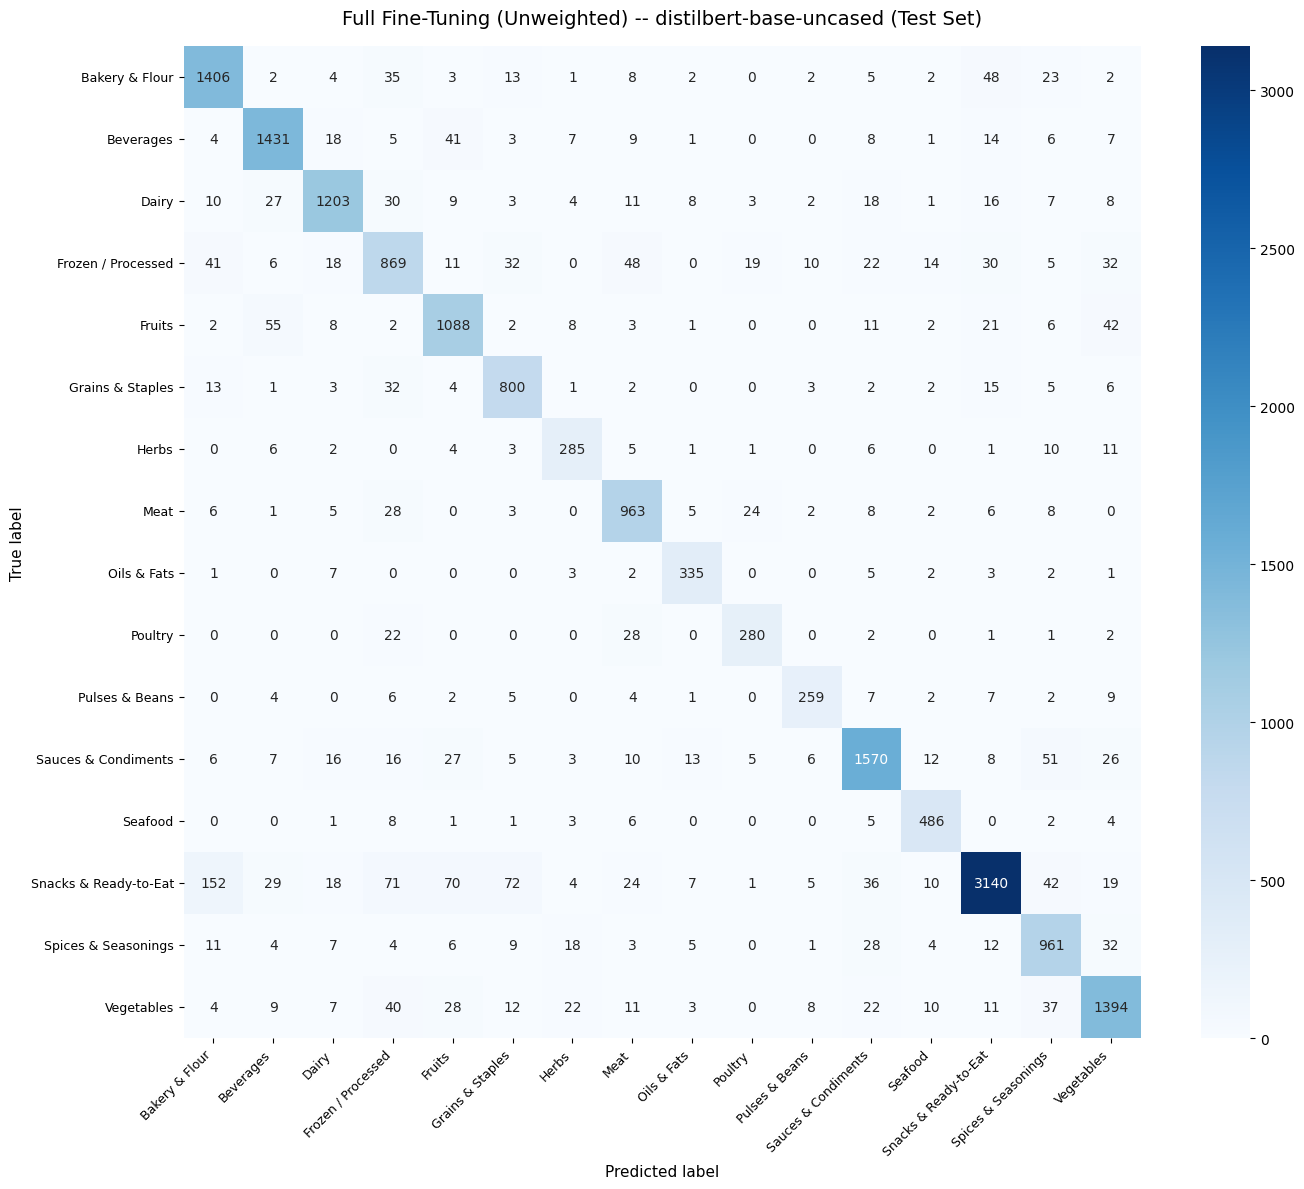

Confusion matrix saved -> results\full_ft_distilbert_unweighted_confusion.png

Metrics saved -> results\full_ft_distilbert_unweighted_results.json


In [5]:
# ═══════════════════════════════════════════════════════════════════
# Cell 11 — Full Fine-Tuning: DistilBERT (Unweighted)
# All layers unfrozen. Discriminative LRs: lower half 1e-5, upper 3e-5.
# Loss: CrossEntropyLoss unweighted.
# ═══════════════════════════════════════════════════════════════════

MODEL_NAME = "distilbert-base-uncased"
CKPT_PATH  = os.path.join(config["checkpoint_dir"], "full_ft_distilbert_unweighted_best.pt")
CM_PATH    = os.path.join(config["results_dir"],    "full_ft_distilbert_unweighted_confusion.png")
JSON_PATH  = os.path.join(config["results_dir"],    "full_ft_distilbert_unweighted_results.json")

LR_LOWER = 1e-5   # embeddings + transformer layers 0–2
LR_UPPER = 3e-5   # transformer layers 3–5 + classification head

print(f"{'='*60}")
print(f"  Full Fine-Tuning (Unweighted): {MODEL_NAME}")
print(f"  Discriminative LR — lower half: {LR_LOWER}  |  upper half: {LR_UPPER}")
print(f"{'='*60}")

# ── DataLoaders ───────────────────────────────────────────────────
_, train_loader, val_loader, test_loader = get_dataloaders(MODEL_NAME)

# ── Model — ALL layers unfrozen ───────────────────────────────────
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=config["num_labels"],
    id2label=id2label,
    label2id=label2id,
).to(config["device"])

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total params    : {total:,}")
print(f"  Trainable params: {trainable:,}  ({100*trainable/total:.2f}% — all layers)")

# ── Discriminative LR: 2-group split via named_parameters() ──────
# Group 1 (lower half): embeddings + transformer layers 0, 1, 2
# Group 2 (upper half): transformer layers 3, 4, 5 + head
_lower_prefixes = (
    "distilbert.embeddings.",
    "distilbert.transformer.layer.0.",
    "distilbert.transformer.layer.1.",
    "distilbert.transformer.layer.2.",
)
_lower_params, _upper_params = [], []
for _name, _param in model.named_parameters():
    if any(_name.startswith(_pfx) for _pfx in _lower_prefixes):
        _lower_params.append(_param)
    else:
        _upper_params.append(_param)

print(f"  LR group 1 (lower half): {len(_lower_params)} param tensors  lr={LR_LOWER}")
print(f"  LR group 2 (upper half): {len(_upper_params)} param tensors  lr={LR_UPPER}")

optimizer = AdamW([
    {"params": _lower_params, "lr": LR_LOWER},
    {"params": _upper_params, "lr": LR_UPPER},
])

total_steps  = len(train_loader) * config["epochs"]
warmup_steps = int(config["warmup_ratio"] * total_steps)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)
loss_fn = nn.CrossEntropyLoss()   # unweighted

print(f"  Total steps : {total_steps:,}  |  Warmup steps: {warmup_steps:,} "
      f"({config['warmup_ratio']*100:.0f}%)")

# ── Training loop with early stopping on val macro-F1 ─────────────
best_val_f1, patience_count, best_epoch = -1.0, 0, 0
history = []

print(f"\n{'Epoch':>5}  {'Train Loss':>10}  {'Val Loss':>8}  "
      f"{'Val Acc':>7}  {'Val F1':>7}  Best?")
print("-" * 58)

for epoch in range(1, config["epochs"] + 1):
    tr_loss = train_epoch(
        model, train_loader, optimizer, loss_fn, config["device"],
        scheduler=scheduler,
    )
    val_m   = evaluate(model, val_loader, loss_fn, config["device"])
    is_best = val_m["macro_f1"] > best_val_f1

    if is_best:
        best_val_f1    = val_m["macro_f1"]
        best_epoch     = epoch
        patience_count = 0
        torch.save(model.state_dict(), CKPT_PATH)
    else:
        patience_count += 1

    flag = "<-- best" if is_best else ""
    print(f"{epoch:>5}  {tr_loss:>10.4f}  {val_m['loss']:>8.4f}  "
          f"{val_m['accuracy']:>7.4f}  {val_m['macro_f1']:>7.4f}  {flag}")
    history.append({
        "epoch":        epoch,
        "train_loss":   round(tr_loss, 6),
        "val_loss":     round(val_m["loss"],     6),
        "val_accuracy": round(val_m["accuracy"], 6),
        "val_macro_f1": round(val_m["macro_f1"], 6),
    })

    if patience_count >= config["patience"]:
        print(f"\nEarly stopping at epoch {epoch} "
              f"(no val F1 improvement for {config['patience']} epochs).")
        break

print(f"\nBest checkpoint: epoch {best_epoch}  |  val macro-F1 = {best_val_f1:.4f}")
print(f"Checkpoint saved -> {CKPT_PATH}")

# ── Evaluate on test set using best checkpoint ────────────────────
print("\nLoading best checkpoint for test evaluation...")
model.load_state_dict(
    torch.load(CKPT_PATH, map_location=config["device"], weights_only=True)
)
test_m = evaluate(model, test_loader, loss_fn, config["device"])

print(f"\nTest Results -- {MODEL_NAME}  [Full FT, Unweighted]")
print(f"  Accuracy : {test_m['accuracy']:.4f}")
print(f"  Macro-F1 : {test_m['macro_f1']:.4f}")
print("\nPer-class F1:")
for lbl, f1v in sorted(test_m["per_class_f1"].items()):
    print(f"  {lbl:<30} {f1v:.4f}")
print("\nClassification Report:")
print(classification_report(
    test_m["all_labels"], test_m["all_preds"],
    target_names=CATEGORIES, zero_division=0,
))

# ── Save confusion matrix ─────────────────────────────────────────
cm = confusion_matrix(
    test_m["all_labels"], test_m["all_preds"],
    labels=list(range(len(CATEGORIES))),
)
plot_confusion_matrix(cm, f"Full Fine-Tuning (Unweighted) -- {MODEL_NAME} (Test Set)", CM_PATH)

# ── Save metrics to JSON immediately after evaluation ─────────────
results_full_ft_distilbert_unwt = {
    "model":             MODEL_NAME,
    "method":            "full_finetune_unweighted",
    "test_accuracy":     round(test_m["accuracy"], 6),
    "test_macro_f1":     round(test_m["macro_f1"],  6),
    "per_class_f1":      test_m["per_class_f1"],
    "best_val_macro_f1": round(best_val_f1, 6),
    "best_epoch":        best_epoch,
    "lr_lower":          LR_LOWER,
    "lr_upper":          LR_UPPER,
    "training_history":  history,
    "checkpoint":        CKPT_PATH,
}
with open(JSON_PATH, "w") as f:
    json.dump(results_full_ft_distilbert_unwt, f, indent=2)
print(f"\nMetrics saved -> {JSON_PATH}")

  Full Fine-Tuning (Weighted): distilbert-base-uncased
  Discriminative LR — lower half: 1e-05  |  upper half: 3e-05
Class weights (computed from training set):
  Bakery & Flour                 0.7967
  Beverages                      0.7967
  Dairy                          0.7967
  Frozen / Processed             0.7967
  Fruits                         0.7967
  Grains & Staples               0.8961
  Herbs                          2.3799
  Meat                           0.7967
  Oils & Fats                    2.2061
  Poultry                        2.3658
  Pulses & Beans                 2.5845
  Sauces & Condiments            0.7967
  Seafood                        1.5413
  Snacks & Ready-to-Eat          0.7967
  Spices & Seasonings            0.7967
  Vegetables                     0.7967
  [distilbert-base-uncased]  train=101,974  val=18,889  test=18,890


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 11051.60it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  Total params    : 66,965,776
  Trainable params: 66,965,776  (100.00% — all layers)
  LR group 1 (lower half): 52 param tensors  lr=1e-05
  LR group 2 (upper half): 52 param tensors  lr=3e-05
  Total steps : 47,805  |  Warmup steps: 2,868 (6%)

Epoch  Train Loss  Val Loss  Val Acc   Val F1  Best?
----------------------------------------------------------
    1      1.1879    0.6318   0.7954   0.7745  <-- best
    2      0.4763    0.4556   0.8440   0.8331  <-- best
    3      0.3441    0.4167   0.8587   0.8467  <-- best
    4      0.2631    0.4128   0.8631   0.8541  <-- best
    5      0.2058    0.4429   0.8618   0.8536  
    6      0.1648    0.4257   0.8739   0.8669  <-- best
    7      0.1340    0.4631   0.8691   0.8606  
    8      0.1070    0.5022   0.8679   0.8630  
    9      0.0888    0.5276   0.8706   0.8665  

Early stopping at epoch 9 (no val F1 improvement for 3 epochs).

Best checkpoint: epoch 6  |  val macro-F1 = 0.8669
Checkpoint saved -> checkpoints\full_ft_distilbert_

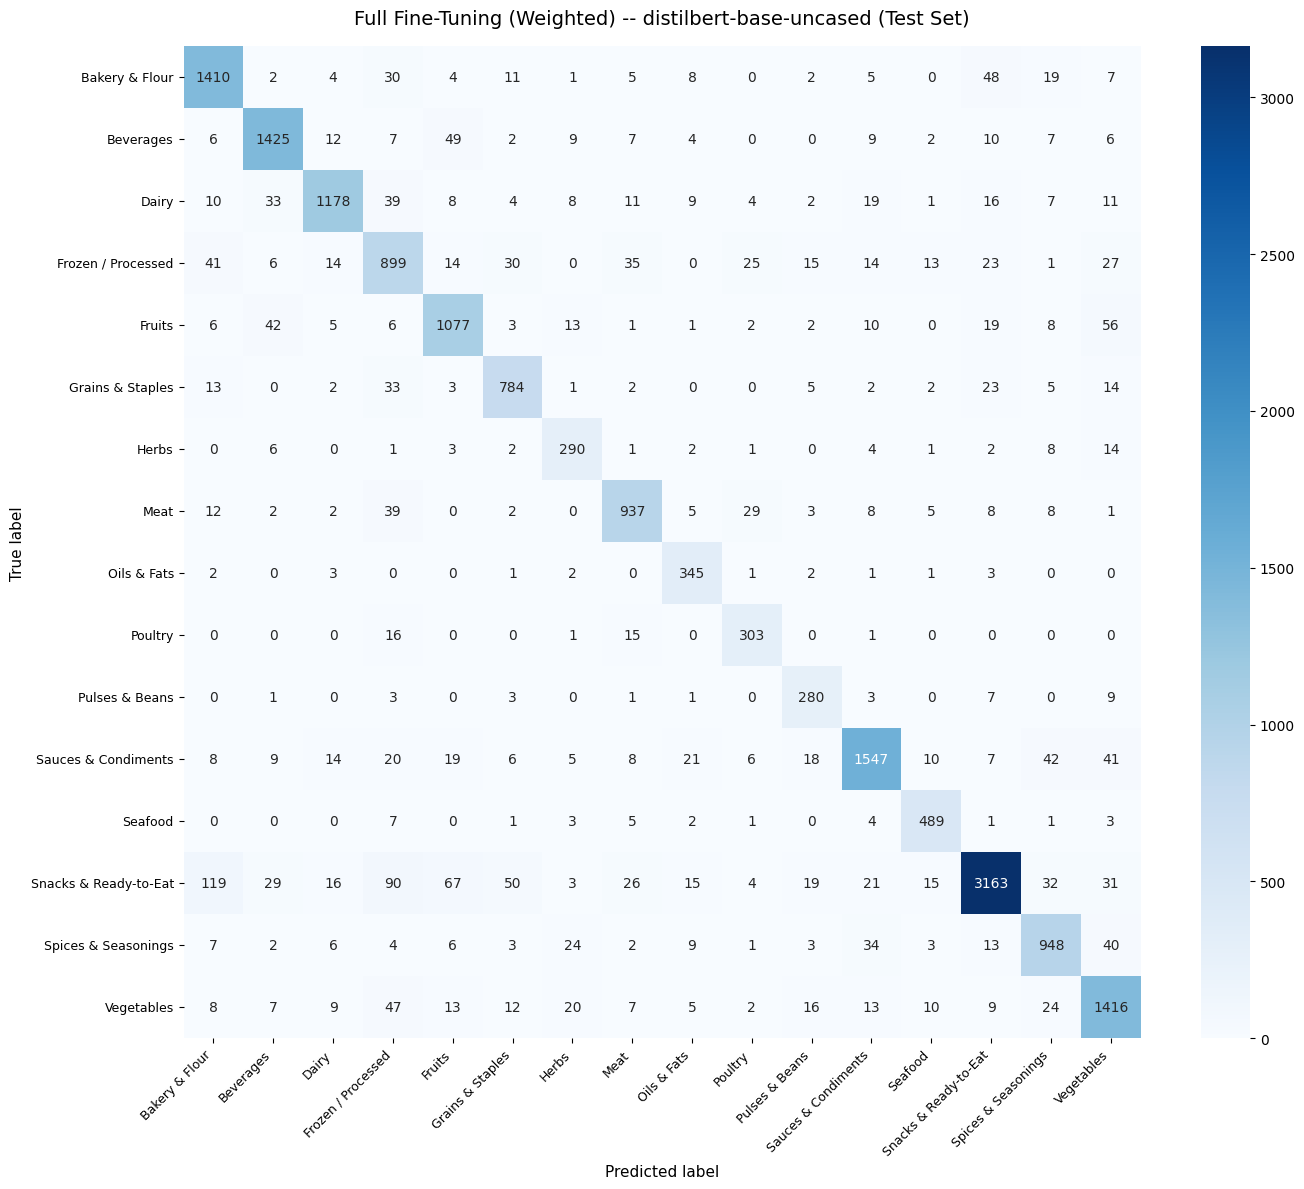

Confusion matrix saved -> results\full_ft_distilbert_weighted_confusion.png

Metrics saved -> results\full_ft_distilbert_weighted_results.json


In [6]:
# ═══════════════════════════════════════════════════════════════════
# Cell 12 — Full Fine-Tuning: DistilBERT (Weighted)
# Identical to Cell 11 except CrossEntropyLoss uses class weights
# computed from the training set only.
# ═══════════════════════════════════════════════════════════════════

MODEL_NAME = "distilbert-base-uncased"
CKPT_PATH  = os.path.join(config["checkpoint_dir"], "full_ft_distilbert_weighted_best.pt")
CM_PATH    = os.path.join(config["results_dir"],    "full_ft_distilbert_weighted_confusion.png")
JSON_PATH  = os.path.join(config["results_dir"],    "full_ft_distilbert_weighted_results.json")

LR_LOWER = 1e-5   # embeddings + transformer layers 0–2
LR_UPPER = 3e-5   # transformer layers 3–5 + classification head

print(f"{'='*60}")
print(f"  Full Fine-Tuning (Weighted): {MODEL_NAME}")
print(f"  Discriminative LR — lower half: {LR_LOWER}  |  upper half: {LR_UPPER}")
print(f"{'='*60}")

# ── Compute class weights from TRAINING SET only ──────────────────
# weight[c] = total_samples / (num_classes * samples_in_class)
_df_train = pd.read_csv(os.path.join(config["splits_dir"], "train_downsampled.csv"))
_total    = len(_df_train)
_n_cls    = config["num_labels"]
_counts   = _df_train["predicted_label"].value_counts()

class_weights = torch.zeros(_n_cls, dtype=torch.float)
for _i, _cat in enumerate(CATEGORIES):
    _cnt = int(_counts.get(_cat, 1))
    class_weights[_i] = _total / (_n_cls * _cnt)

class_weights = class_weights.to(config["device"])
print("Class weights (computed from training set):")
for _i, _cat in enumerate(CATEGORIES):
    print(f"  {_cat:<30} {class_weights[_i].item():.4f}")

# ── DataLoaders ───────────────────────────────────────────────────
_, train_loader, val_loader, test_loader = get_dataloaders(MODEL_NAME)

# ── Model — ALL layers unfrozen ───────────────────────────────────
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=config["num_labels"],
    id2label=id2label,
    label2id=label2id,
).to(config["device"])

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n  Total params    : {total:,}")
print(f"  Trainable params: {trainable:,}  ({100*trainable/total:.2f}% — all layers)")

# ── Discriminative LR: 2-group split via named_parameters() ──────
_lower_prefixes = (
    "distilbert.embeddings.",
    "distilbert.transformer.layer.0.",
    "distilbert.transformer.layer.1.",
    "distilbert.transformer.layer.2.",
)
_lower_params, _upper_params = [], []
for _name, _param in model.named_parameters():
    if any(_name.startswith(_pfx) for _pfx in _lower_prefixes):
        _lower_params.append(_param)
    else:
        _upper_params.append(_param)

print(f"  LR group 1 (lower half): {len(_lower_params)} param tensors  lr={LR_LOWER}")
print(f"  LR group 2 (upper half): {len(_upper_params)} param tensors  lr={LR_UPPER}")

optimizer = AdamW([
    {"params": _lower_params, "lr": LR_LOWER},
    {"params": _upper_params, "lr": LR_UPPER},
])

total_steps  = len(train_loader) * config["epochs"]
warmup_steps = int(config["warmup_ratio"] * total_steps)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)   # weighted

print(f"  Total steps : {total_steps:,}  |  Warmup steps: {warmup_steps:,} "
      f"({config['warmup_ratio']*100:.0f}%)")

# ── Training loop with early stopping on val macro-F1 ─────────────
best_val_f1, patience_count, best_epoch = -1.0, 0, 0
history = []

print(f"\n{'Epoch':>5}  {'Train Loss':>10}  {'Val Loss':>8}  "
      f"{'Val Acc':>7}  {'Val F1':>7}  Best?")
print("-" * 58)

for epoch in range(1, config["epochs"] + 1):
    tr_loss = train_epoch(
        model, train_loader, optimizer, loss_fn, config["device"],
        scheduler=scheduler,
    )
    val_m   = evaluate(model, val_loader, loss_fn, config["device"])
    is_best = val_m["macro_f1"] > best_val_f1

    if is_best:
        best_val_f1    = val_m["macro_f1"]
        best_epoch     = epoch
        patience_count = 0
        torch.save(model.state_dict(), CKPT_PATH)
    else:
        patience_count += 1

    flag = "<-- best" if is_best else ""
    print(f"{epoch:>5}  {tr_loss:>10.4f}  {val_m['loss']:>8.4f}  "
          f"{val_m['accuracy']:>7.4f}  {val_m['macro_f1']:>7.4f}  {flag}")
    history.append({
        "epoch":        epoch,
        "train_loss":   round(tr_loss, 6),
        "val_loss":     round(val_m["loss"],     6),
        "val_accuracy": round(val_m["accuracy"], 6),
        "val_macro_f1": round(val_m["macro_f1"], 6),
    })

    if patience_count >= config["patience"]:
        print(f"\nEarly stopping at epoch {epoch} "
              f"(no val F1 improvement for {config['patience']} epochs).")
        break

print(f"\nBest checkpoint: epoch {best_epoch}  |  val macro-F1 = {best_val_f1:.4f}")
print(f"Checkpoint saved -> {CKPT_PATH}")

# ── Evaluate on test set using best checkpoint ────────────────────
print("\nLoading best checkpoint for test evaluation...")
model.load_state_dict(
    torch.load(CKPT_PATH, map_location=config["device"], weights_only=True)
)
test_m = evaluate(model, test_loader, loss_fn, config["device"])

print(f"\nTest Results -- {MODEL_NAME}  [Full FT, Weighted]")
print(f"  Accuracy : {test_m['accuracy']:.4f}")
print(f"  Macro-F1 : {test_m['macro_f1']:.4f}")
print("\nPer-class F1:")
for lbl, f1v in sorted(test_m["per_class_f1"].items()):
    print(f"  {lbl:<30} {f1v:.4f}")
print("\nClassification Report:")
print(classification_report(
    test_m["all_labels"], test_m["all_preds"],
    target_names=CATEGORIES, zero_division=0,
))

# ── Save confusion matrix ─────────────────────────────────────────
cm = confusion_matrix(
    test_m["all_labels"], test_m["all_preds"],
    labels=list(range(len(CATEGORIES))),
)
plot_confusion_matrix(cm, f"Full Fine-Tuning (Weighted) -- {MODEL_NAME} (Test Set)", CM_PATH)

# ── Save metrics to JSON immediately after evaluation ─────────────
results_full_ft_distilbert_wt = {
    "model":             MODEL_NAME,
    "method":            "full_finetune_weighted",
    "test_accuracy":     round(test_m["accuracy"], 6),
    "test_macro_f1":     round(test_m["macro_f1"],  6),
    "per_class_f1":      test_m["per_class_f1"],
    "best_val_macro_f1": round(best_val_f1, 6),
    "best_epoch":        best_epoch,
    "lr_lower":          LR_LOWER,
    "lr_upper":          LR_UPPER,
    "class_weights":     {CATEGORIES[i]: round(float(class_weights[i].item()), 6)
                          for i in range(len(CATEGORIES))},
    "training_history":  history,
    "checkpoint":        CKPT_PATH,
}
with open(JSON_PATH, "w") as f:
    json.dump(results_full_ft_distilbert_wt, f, indent=2)
print(f"\nMetrics saved -> {JSON_PATH}")

In [9]:
def build_lora_model(model_name: str) -> nn.Module:
    """Load AutoModelForSequenceClassification and wrap with LoRA adapters.
    Reads all LoRA hyperparameters from the global config dict.
    Defined here for reuse in Cell 9.
    """
    base = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=config["num_labels"],
        id2label=id2label,
        label2id=label2id,
    )
    peft_cfg = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=config["lora_r"],
        lora_alpha=config["lora_alpha"],
        lora_dropout=config["lora_dropout"],
        bias=config["lora_bias"],
        target_modules=config["lora_targets"][model_name],
    )
    model = get_peft_model(base, peft_cfg)
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Total params    : {total:,}")
    print(f"  Trainable params: {trainable:,}  "
          f"({100 * trainable / total:.3f}% -- LoRA adapters + classifier head)")
    return model

  LoRA Fine-tuning (Weighted): distilbert-base-uncased
Class weights (computed from training set):
  Bakery & Flour                 0.7967
  Beverages                      0.7967
  Dairy                          0.7967
  Frozen / Processed             0.7967
  Fruits                         0.7967
  Grains & Staples               0.8961
  Herbs                          2.3799
  Meat                           0.7967
  Oils & Fats                    2.2061
  Poultry                        2.3658
  Pulses & Beans                 2.5845
  Sauces & Condiments            0.7967
  Seafood                        1.5413
  Snacks & Ready-to-Eat          0.7967
  Spices & Seasonings            0.7967
  Vegetables                     0.7967
  [distilbert-base-uncased]  train=101,974  val=18,889  test=18,890


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7582.31it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Total params    : 67,716,128
  Trainable params: 750,352  (1.108% -- LoRA adapters + classifier head)


`use_return_dict` is deprecated! Use `return_dict` instead!


  Total steps : 47,805  |  Warmup steps: 2,868 (6%)

Epoch  Train Loss  Val Loss  Val Acc   Val F1  Best?
----------------------------------------------------------
    1      1.2775    0.7480   0.7551   0.7434  <-- best
    2      0.7018    0.6080   0.7966   0.7853  <-- best
    3      0.5840    0.5479   0.8142   0.7999  <-- best
    4      0.5191    0.5204   0.8227   0.8117  <-- best
    5      0.4699    0.5142   0.8238   0.8123  <-- best
    6      0.4378    0.4698   0.8375   0.8256  <-- best
    7      0.4075    0.4702   0.8411   0.8298  <-- best
    8      0.3815    0.4568   0.8431   0.8317  <-- best
    9      0.3614    0.4445   0.8480   0.8378  <-- best
   10      0.3436    0.4298   0.8525   0.8414  <-- best
   11      0.3299    0.4347   0.8518   0.8404  
   12      0.3156    0.4309   0.8528   0.8413  
   13      0.3057    0.4266   0.8550   0.8436  <-- best
   14      0.2974    0.4284   0.8529   0.8423  
   15      0.2898    0.4276   0.8544   0.8441  <-- best

Best checkpoint: e

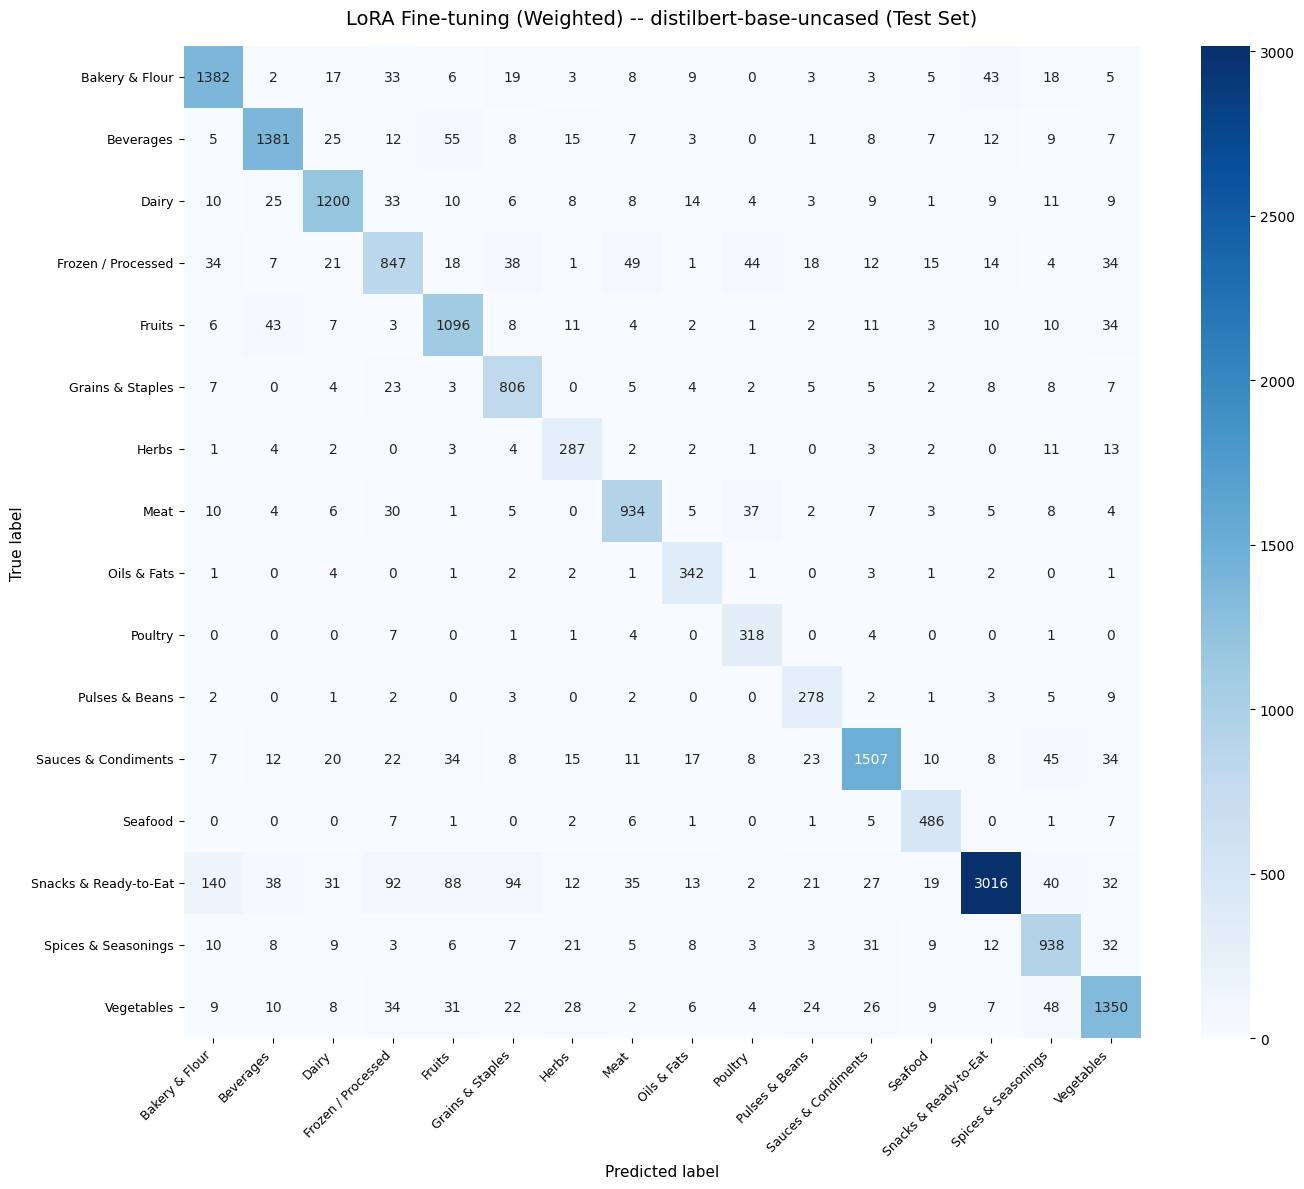

Confusion matrix saved -> results\lora_distilbert_weighted_confusion.png

Metrics saved -> results\lora_distilbert_weighted_results.json


In [10]:
# ═══════════════════════════════════════════════════════════════════
# Cell 13 — LoRA Fine-Tuning: DistilBERT (Weighted)
# Identical to Cell 8 (LoRA unweighted) except CrossEntropyLoss uses
# class weights computed from the training set only.
# LoRA config, optimizer, and scheduler are unchanged from Cell 8.
# ═══════════════════════════════════════════════════════════════════

MODEL_NAME  = "distilbert-base-uncased"
TMP_CKPT    = os.path.join(config["checkpoint_dir"], "lora_distilbert_weighted_tmp.pt")
ADAPTER_DIR = os.path.join(config["checkpoint_dir"], "lora_distilbert_weighted_adapter")
MERGED_PT   = os.path.join(config["checkpoint_dir"], "lora_distilbert_weighted_merged.pt")
CM_PATH     = os.path.join(config["results_dir"],    "lora_distilbert_weighted_confusion.png")
JSON_PATH   = os.path.join(config["results_dir"],    "lora_distilbert_weighted_results.json")

print(f"{'='*60}")
print(f"  LoRA Fine-tuning (Weighted): {MODEL_NAME}")
print(f"{'='*60}")

# ── Compute class weights from TRAINING SET only ──────────────────
# weight[c] = total_samples / (num_classes * samples_in_class)
_df_train = pd.read_csv(os.path.join(config["splits_dir"], "train_downsampled.csv"))
_total    = len(_df_train)
_n_cls    = config["num_labels"]
_counts   = _df_train["predicted_label"].value_counts()

class_weights = torch.zeros(_n_cls, dtype=torch.float)
for _i, _cat in enumerate(CATEGORIES):
    _cnt = int(_counts.get(_cat, 1))
    class_weights[_i] = _total / (_n_cls * _cnt)

class_weights = class_weights.to(config["device"])
print("Class weights (computed from training set):")
for _i, _cat in enumerate(CATEGORIES):
    print(f"  {_cat:<30} {class_weights[_i].item():.4f}")

# ── DataLoaders ───────────────────────────────────────────────────
_, train_loader, val_loader, test_loader = get_dataloaders(MODEL_NAME)

# ── Model — reuse build_lora_model from Cell 8 ───────────────────
model = build_lora_model(MODEL_NAME).to(config["device"])

# ── Optimizer, scheduler (unchanged from Cell 8) ─────────────────
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=config["lr_lora"],
)
total_steps  = len(train_loader) * config["epochs"]
warmup_steps = int(config["warmup_ratio"] * total_steps)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)   # weighted — only change

print(f"  Total steps : {total_steps:,}  |  Warmup steps: {warmup_steps:,} "
      f"({config['warmup_ratio']*100:.0f}%)")

# ── Training loop with early stopping on val macro-F1 ─────────────
best_val_f1, patience_count, best_epoch = -1.0, 0, 0
history = []

print(f"\n{'Epoch':>5}  {'Train Loss':>10}  {'Val Loss':>8}  "
      f"{'Val Acc':>7}  {'Val F1':>7}  Best?")
print("-" * 58)

for epoch in range(1, config["epochs"] + 1):
    tr_loss = train_epoch(
        model, train_loader, optimizer, loss_fn, config["device"],
        scheduler=scheduler,
    )
    val_m   = evaluate(model, val_loader, loss_fn, config["device"])
    is_best = val_m["macro_f1"] > best_val_f1

    if is_best:
        best_val_f1    = val_m["macro_f1"]
        best_epoch     = epoch
        patience_count = 0
        torch.save(model.state_dict(), TMP_CKPT)
    else:
        patience_count += 1

    flag = "<-- best" if is_best else ""
    print(f"{epoch:>5}  {tr_loss:>10.4f}  {val_m['loss']:>8.4f}  "
          f"{val_m['accuracy']:>7.4f}  {val_m['macro_f1']:>7.4f}  {flag}")
    history.append({
        "epoch":        epoch,
        "train_loss":   round(tr_loss, 6),
        "val_loss":     round(val_m["loss"],     6),
        "val_accuracy": round(val_m["accuracy"], 6),
        "val_macro_f1": round(val_m["macro_f1"], 6),
    })

    if patience_count >= config["patience"]:
        print(f"\nEarly stopping at epoch {epoch} "
              f"(no val F1 improvement for {config['patience']} epochs).")
        break

print(f"\nBest checkpoint: epoch {best_epoch}  |  val macro-F1 = {best_val_f1:.4f}")

# ── Save model weights immediately after training completes ───────
model.load_state_dict(
    torch.load(TMP_CKPT, map_location=config["device"], weights_only=True)
)

# 1. Save PEFT adapter
os.makedirs(ADAPTER_DIR, exist_ok=True)
model.save_pretrained(ADAPTER_DIR)
print(f"PEFT adapter saved  -> {ADAPTER_DIR}")

# 2. Merge and save full state dict
merged_model = model.merge_and_unload()
torch.save(merged_model.state_dict(), MERGED_PT)
print(f"Merged model saved  -> {MERGED_PT}")

# ── Evaluate on test set (merged model) ───────────────────────────
print("\nEvaluating on test set (merged model)...")
test_m = evaluate(merged_model, test_loader, loss_fn, config["device"])

print(f"\nTest Results -- {MODEL_NAME}  [LoRA, Weighted]")
print(f"  Accuracy : {test_m['accuracy']:.4f}")
print(f"  Macro-F1 : {test_m['macro_f1']:.4f}")
print("\nPer-class F1:")
for lbl, f1v in sorted(test_m["per_class_f1"].items()):
    print(f"  {lbl:<30} {f1v:.4f}")
print("\nClassification Report:")
print(classification_report(
    test_m["all_labels"], test_m["all_preds"],
    target_names=CATEGORIES, zero_division=0,
))

# ── Save confusion matrix ─────────────────────────────────────────
cm = confusion_matrix(
    test_m["all_labels"], test_m["all_preds"],
    labels=list(range(len(CATEGORIES))),
)
plot_confusion_matrix(cm, f"LoRA Fine-tuning (Weighted) -- {MODEL_NAME} (Test Set)", CM_PATH)

# ── Save metrics to JSON immediately after evaluation ─────────────
results_lora_distilbert_wt = {
    "model":             MODEL_NAME,
    "method":            "lora_weighted",
    "test_accuracy":     round(test_m["accuracy"], 6),
    "test_macro_f1":     round(test_m["macro_f1"],  6),
    "per_class_f1":      test_m["per_class_f1"],
    "best_val_macro_f1": round(best_val_f1, 6),
    "best_epoch":        best_epoch,
    "class_weights":     {CATEGORIES[i]: round(float(class_weights[i].item()), 6)
                          for i in range(len(CATEGORIES))},
    "training_history":  history,
    "adapter_dir":       ADAPTER_DIR,
    "merged_checkpoint": MERGED_PT,
}
with open(JSON_PATH, "w") as f:
    json.dump(results_lora_distilbert_wt, f, indent=2)
print(f"\nMetrics saved -> {JSON_PATH}")

if os.path.exists(TMP_CKPT):
    os.remove(TMP_CKPT)

In [11]:
# ═══════════════════════════════════════════════════════════════════
# Cell 14 — DistilBERT Full Comparison (4 conditions)
# Self-contained: loads from saved JSON files only.
# No models in memory. No training.
# ═══════════════════════════════════════════════════════════════════

import json as _json, os as _os
import pandas as _pd

_rdir = config["results_dir"] if "config" in dir() else "results"

_result_files = {
    "LoRA-Unwt":  _os.path.join(_rdir, "lora_distilbert_results.json"),
    "LoRA-Wtd":   _os.path.join(_rdir, "lora_distilbert_weighted_results.json"),
    "FFT-Unwt":   _os.path.join(_rdir, "full_ft_distilbert_unweighted_results.json"),
    "FFT-Wtd":    _os.path.join(_rdir, "full_ft_distilbert_weighted_results.json"),
}

_all_data = {}
for _label, _path in _result_files.items():
    if _os.path.exists(_path):
        with open(_path) as _f:
            _all_data[_label] = _json.load(_f)
    else:
        print(f"WARNING: {_path} not found -- skipping {_label}.")

if not _all_data:
    raise FileNotFoundError(
        "No result files found. Run Cells 8, 11, 12, 13 first."
    )

# ── Summary table ─────────────────────────────────────────────────
print("=" * 68)
print("  DISTILBERT: LoRA vs Full FT  |  Unweighted vs Weighted")
print("=" * 68)

_col_order = ["LoRA-Unwt", "LoRA-Wtd", "FFT-Unwt", "FFT-Wtd"]
_available = [c for c in _col_order if c in _all_data]

_rows = []
for _metric, _key in [
    ("Test Accuracy", "test_accuracy"),
    ("Test Macro-F1", "test_macro_f1"),
    ("Best Val F1",   "best_val_macro_f1"),
    ("Best Epoch",    "best_epoch"),
]:
    _row = {"Metric": _metric}
    for _col in _available:
        _v = _all_data[_col].get(_key, "n/a")
        _row[_col] = f"{_v:.4f}" if isinstance(_v, float) else str(_v)
    _rows.append(_row)

_sum_df = _pd.DataFrame(_rows).set_index("Metric")
_sum_df = _sum_df[[c for c in _available]]
print(_sum_df.to_string())

# ── Per-class F1 with best-per-class highlighting ─────────────────
print("\nPer-class F1 (best value per category marked with *):\n")
_pc_df = _pd.DataFrame({
    _col: _all_data[_col]["per_class_f1"]
    for _col in _available
}).sort_index()
_pc_df.index.name = "Category"

_display_rows = []
for _cat, _row in _pc_df.iterrows():
    _best = _row.max()
    _marked = {
        _col: (f"{_v:.4f}*" if _v == _best else f"{_v:.4f}")
        for _col, _v in _row.items()
    }
    _marked["Category"] = _cat
    _display_rows.append(_marked)

_display_df = _pd.DataFrame(_display_rows).set_index("Category")
_display_df = _display_df[[c for c in _available]]
print(_display_df.to_string())

  DISTILBERT: LoRA vs Full FT  |  Unweighted vs Weighted
              LoRA-Unwt LoRA-Wtd FFT-Unwt FFT-Wtd
Metric                                           
Test Accuracy    0.8600   0.8559   0.8719  0.8730
Test Macro-F1    0.8527   0.8462   0.8656  0.8646
Best Val F1      0.8542   0.8441   0.8668  0.8669
Best Epoch           14       15        9       6

Per-class F1 (best value per category marked with *):

                      LoRA-Unwt LoRA-Wtd FFT-Unwt  FFT-Wtd
Category                                                  
Bakery & Flour           0.8669   0.8692   0.8755  0.8818*
Beverages                0.8963   0.8941   0.9123  0.9138*
Dairy                    0.8855   0.8840  0.8988*   0.8975
Frozen / Processed       0.7407   0.7349   0.7475  0.7498*
Fruits                   0.8377   0.8418   0.8550  0.8568*
Grains & Staples         0.8431   0.8396   0.8639  0.8697*
Herbs                    0.8118   0.7746  0.8213*   0.8112
Meat                     0.8700   0.8713   0.8763  0.882